# Treinamento e Validação do Modelo

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)

## Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython import get_ipython

from typing import Any
from pathlib import Path
from dataclasses import dataclass

from xgboost import XGBClassifier
from tqdm.auto import tqdm

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

/home/miguel/Documents/processos_seletivos/desafio_tecnico_industriall/ps-industriall-estagio-ml/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurações

In [2]:
@dataclass(frozen=True)
class TemporalTrainingConfig:
    timestamp_col: str = "timestamp"
    state_target_col: str = "target"
    target_col: str = "target_2h"
    horizon: str = "2h"
    boundary_buffer: str = "6h"
    n_validation_events: int = 3
    n_test_events: int = 1

    # F2 dá mais peso ao recall.
    threshold_beta: float = 2.0
    threshold_quantiles: int = 201

    random_state: int = 42

## Funções

In [3]:
def preparar_dataframe_temporal(
    df: pd.DataFrame,
    config: TemporalTrainingConfig,
) -> tuple[pd.DataFrame, pd.Timedelta, list[str], pd.DataFrame]:
    """
    Ordena o dataframe, valida a frequência temporal e seleciona as features.

    Todos os campos target são removidos das features para evitar vazamento.
    """

    data = df.copy()

    required_columns = {
        config.state_target_col,
        config.target_col,
    }
    missing_columns = required_columns.difference(data.columns)

    if missing_columns:
        raise ValueError(f"Colunas ausentes: {sorted(missing_columns)}")

    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError(
            "O índice precisa ser um DatetimeIndex."
        )

    data = data.sort_index()
    data.index.name = config.timestamp_col

    if data.index.has_duplicates:
        raise ValueError("O índice temporal possui timestamps duplicados.")

    timestamp_diffs = (
        data.index
        .to_series()
        .diff()
        .dropna()
    )

    if timestamp_diffs.empty:
        raise ValueError("São necessários pelo menos dois timestamps.")

    if timestamp_diffs.nunique() != 1:
        raise ValueError("A frequência temporal precisa ser regular.")

    temporal_step = timestamp_diffs.iloc[0]
    failure_events = obter_eventos_falha(
        data=data,
        state_target_col=config.state_target_col,
        temporal_step=temporal_step,
    )

    # Remove todos os targets, e não apenas o target atual.
    target_columns = [
        column
        for column in data.columns
        if column == "target"
        or column.startswith("target_")
    ]

    feature_columns = [
        column
        for column in data.columns
        if column != config.timestamp_col
        and column not in target_columns
    ]

    if not feature_columns:
        raise ValueError("Nenhuma feature foi encontrada.")

    invalid_features = [
        column
        for column in feature_columns
        if not (
            pd.api.types.is_numeric_dtype(data[column])
            or pd.api.types.is_bool_dtype(data[column])
        )
    ]

    if invalid_features:
        raise TypeError(
            "As seguintes features não são numéricas: "
            f"{invalid_features}"
        )

    # XGBoost aceita NaN, mas não deve receber infinito.
    data[feature_columns] = (
        data[feature_columns]
        .replace([np.inf, -np.inf], np.nan)
    )

    data[config.target_col] = data[config.target_col].astype("Int8")

    return data, temporal_step, feature_columns, failure_events

In [4]:
def obter_eventos_falha(
    data: pd.DataFrame,
    state_target_col: str,
    temporal_step: pd.Timedelta,
) -> pd.DataFrame:
    estado = data[state_target_col]

    if estado.isna().any():
        raise ValueError("O estado de falha possui valores ausentes.")

    invalid_values = set(estado.unique()).difference({0, 1, False, True})
    if invalid_values:
        raise ValueError(f"Estados de falha inválidos: {invalid_values}")

    falha = estado.astype(bool)
    starts = data.index[falha & ~falha.shift(fill_value=False)]
    ends = data.index[falha & ~falha.shift(-1, fill_value=False)]

    if len(starts) != len(ends):
        raise ValueError("Não foi possível parear os eventos de falha.")

    events = pd.DataFrame({
        "event_id": np.arange(1, len(starts) + 1),
        "start": starts,
        "end": ends,
    })
    events["duration"] = (
        events["end"] - events["start"] + temporal_step
    )

    return events


def separar_teste_final(
    data: pd.DataFrame,
    failure_events: pd.DataFrame,
    config: TemporalTrainingConfig,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.Timestamp,
]:
    required_events = (
        config.n_validation_events
        + config.n_test_events
        + 1
    )
    if len(failure_events) < required_events:
        raise ValueError(
            f"São necessários ao menos {required_events} eventos de falha."
        )

    first_test_position = len(failure_events) - config.n_test_events
    previous_event = failure_events.iloc[first_test_position - 1]
    test_start = (
        previous_event["end"]
        + pd.Timedelta(config.boundary_buffer)
    )
    development_end = test_start - pd.Timedelta(config.horizon)

    development = data.loc[data.index < development_end].copy()
    purged = data.loc[
        (data.index >= development_end)
        & (data.index < test_start)
    ].copy()
    test = data.loc[data.index >= test_start].copy()

    development_events = failure_events.iloc[:first_test_position].copy()
    test_events = failure_events.iloc[first_test_position:].copy()

    if development.empty or test.empty:
        raise ValueError("Desenvolvimento ou teste ficou vazio.")

    if not (test_events["start"] >= test_start).all():
        raise ValueError("O teste não contém integralmente os eventos finais.")

    return (
        development,
        purged,
        test,
        development_events,
        test_events,
        test_start,
    )

In [5]:
def criar_folds_eventos(
    development: pd.DataFrame,
    development_events: pd.DataFrame,
    config: TemporalTrainingConfig,
) -> list[dict[str, Any]]:
    validation_events = development_events.tail(
        config.n_validation_events
    )
    folds: list[dict[str, Any]] = []
    horizon = pd.Timedelta(config.horizon)
    buffer = pd.Timedelta(config.boundary_buffer)

    for fold, (_, event) in enumerate(
        validation_events.iterrows(),
        start=1,
    ):
        event_position = int(event["event_id"]) - 1
        previous_event = development_events.iloc[event_position - 1]
        validation_start = previous_event["end"] + buffer
        validation_end = event["end"] + buffer
        train_end = validation_start - horizon

        eligible = development[config.target_col].notna().to_numpy()
        train_index = np.flatnonzero(
            eligible & (development.index < train_end)
        )
        validation_index = np.flatnonzero(
            eligible
            & (development.index >= validation_start)
            & (development.index < validation_end)
        )

        if len(train_index) == 0 or len(validation_index) == 0:
            raise ValueError(f"O fold {fold} ficou vazio.")

        validation_target = development.iloc[validation_index][config.target_col]
        if validation_target.nunique() < 2:
            raise ValueError(f"O fold {fold} não possui as duas classes.")

        if not (validation_start <= event["start"] < validation_end):
            raise ValueError(f"O evento do fold {fold} está fora da validação.")

        folds.append({
            "fold": fold,
            "event_id": int(event["event_id"]),
            "event_start": event["start"],
            "event_end": event["end"],
            "train_end": train_end,
            "validation_start": validation_start,
            "validation_end": validation_end,
            "train_index": train_index,
            "validation_index": validation_index,
        })

    return folds


def calcular_scale_pos_weight(y: pd.Series) -> float:
    positives = int((y == 1).sum())
    negatives = int((y == 0).sum())

    if positives == 0:
        raise ValueError(
            "O conjunto de treino não possui exemplos positivos."
        )

    return negatives / positives

In [6]:
def criar_xgb_classifier(
    scale_pos_weight: float,
    random_state: int,
    n_estimators: int = 4_000,
    early_stopping_rounds: int | None = 100,
    extra_params: dict[str, Any] | None = None,
) -> XGBClassifier:
    params: dict[str, Any] = {
        "objective": "binary:logistic",

        # Métrica apropriada para classes raras.
        "eval_metric": "aucpr",

        "n_estimators": n_estimators,
        "learning_rate": 0.03,

        "max_depth": 6,
        "min_child_weight": 5,
        "gamma": 0.0,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 1.0,

        "scale_pos_weight": scale_pos_weight,

        "tree_method": "hist",
        "random_state": random_state,
        "n_jobs": -1,
    }

    if early_stopping_rounds is not None:
        params["early_stopping_rounds"] = early_stopping_rounds

    if extra_params:
        params.update(extra_params)

    return XGBClassifier(**params)


def criar_classificador(
    nome_modelo: str,
    scale_pos_weight: float,
    random_state: int,
    n_estimators: int = 4_000,
    early_stopping_rounds: int | None = 100,
    extra_params: dict[str, Any] | None = None,
) -> Any:
    if nome_modelo == "DummyClassifier":
        params: dict[str, Any] = {
            "strategy": "stratified",
            "random_state": random_state,
        }
        if extra_params:
            params.update(extra_params)
        return DummyClassifier(**params)

    if nome_modelo == "LogisticRegression":
        params = {
            "class_weight": "balanced",
            "max_iter": 1_000,
            "random_state": random_state,
        }
        if extra_params:
            params.update(extra_params)
        return LogisticRegression(**params)

    if nome_modelo == "XGBoost":
        return criar_xgb_classifier(
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            n_estimators=n_estimators,
            early_stopping_rounds=early_stopping_rounds,
            extra_params=extra_params,
        )

    raise ValueError(f"Modelo não suportado: {nome_modelo}")


def ajustar_preprocessamento(
    X_train: pd.DataFrame,
) -> tuple[np.ndarray, SimpleImputer, StandardScaler]:
    # A interpolação ocorre somente no treino para não utilizar
    # informações da validação ou do teste.
    X_train_interpolated = X_train.interpolate(
        method="linear",
        axis=0,
        limit_direction="both",
    )

    imputer = SimpleImputer(
        strategy="median",
        keep_empty_features=True,
    )
    X_train_imputed = imputer.fit_transform(
        X_train_interpolated
    )

    scaler = StandardScaler()
    X_train_processed = scaler.fit_transform(
        X_train_imputed
    )

    if not np.isfinite(X_train_processed).all():
        raise ValueError("O treino processado possui valores inválidos.")

    return X_train_processed, imputer, scaler


def transformar_features(
    X: pd.DataFrame,
    imputer: SimpleImputer,
    scaler: StandardScaler,
) -> np.ndarray:
    # Validação e teste utilizam exclusivamente os parâmetros
    # aprendidos no respectivo conjunto de treino.
    X_imputed = imputer.transform(X)
    X_processed = scaler.transform(X_imputed)

    if not np.isfinite(X_processed).all():
        raise ValueError("O conjunto processado possui valores inválidos.")

    return X_processed

In [7]:
def avaliar_metricas_registro(
    y_true: pd.Series | np.ndarray,
    probabilities: pd.Series | np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    has_positive = bool((y_true == 1).any())
    has_negative = bool((y_true == 0).any())
    predicted_positive = tp + fp

    precision = tp / predicted_positive if predicted_positive else np.nan
    recall = tp / (tp + fn) if has_positive else np.nan
    f1_denominator = 2 * tp + fp + fn
    f2_denominator = 5 * tp + 4 * fn + fp

    return {
        "record_pr_auc": (
            average_precision_score(y_true, probabilities)
            if has_positive
            else np.nan
        ),
        "record_roc_auc": (
            roc_auc_score(y_true, probabilities)
            if has_positive and has_negative
            else np.nan
        ),
        "record_precision": precision,
        "record_recall": recall,
        "record_f1": (
            2 * tp / f1_denominator if f1_denominator else np.nan
        ),
        "record_f2": (
            5 * tp / f2_denominator if f2_denominator else np.nan
        ),
        "threshold": threshold,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


def gerar_alarmes(
    predictions: pd.DataFrame,
    threshold: float,
    cooldown: pd.Timedelta,
) -> pd.DataFrame:
    candidates = (
        predictions.loc[predictions["probability"] >= threshold]
        .sort_values("timestamp")
    )
    alarms: list[dict[str, Any]] = []
    next_allowed: pd.Timestamp | None = None

    for row in candidates.itertuples(index=False):
        if next_allowed is None or row.timestamp >= next_allowed:
            alarms.append({
                "timestamp": row.timestamp,
                "probability": float(row.probability),
            })
            next_allowed = row.timestamp + cooldown

    return pd.DataFrame(alarms, columns=["timestamp", "probability"])


def avaliar_alarmes(
    predictions: pd.DataFrame,
    failure_events: pd.DataFrame,
    threshold: float,
    horizon: pd.Timedelta,
    beta: float = 2.0,
) -> tuple[dict[str, float], pd.DataFrame]:
    alarms = gerar_alarmes(
        predictions=predictions,
        threshold=threshold,
        cooldown=horizon,
    )
    alarms["matched_event_id"] = pd.Series(dtype="Int64")
    alarms["lead_time_minutes"] = np.nan

    matched_alarm_indices: set[int] = set()
    lead_times: list[float] = []
    detected_events = 0

    for event in failure_events.sort_values("start").itertuples():
        candidates = alarms.index[
            (alarms["timestamp"] >= event.start - horizon)
            & (alarms["timestamp"] < event.start)
            & ~alarms.index.isin(matched_alarm_indices)
        ]
        if len(candidates) == 0:
            continue

        alarm_index = int(candidates[0])
        lead_time = (
            event.start - alarms.at[alarm_index, "timestamp"]
        ) / pd.Timedelta("1min")
        alarms.at[alarm_index, "matched_event_id"] = event.event_id
        alarms.at[alarm_index, "lead_time_minutes"] = float(lead_time)
        matched_alarm_indices.add(alarm_index)
        lead_times.append(float(lead_time))
        detected_events += 1

    total_alarms = len(alarms)
    total_events = len(failure_events)
    false_alarms = total_alarms - detected_events
    event_precision = (
        detected_events / total_alarms if total_alarms else np.nan
    )
    event_recall = (
        detected_events / total_events if total_events else np.nan
    )
    beta_squared = beta**2
    fbeta_denominator = (
        beta_squared * event_precision + event_recall
        if not np.isnan(event_precision) and not np.isnan(event_recall)
        else 0
    )
    event_fbeta = (
        (1 + beta_squared) * event_precision * event_recall
        / fbeta_denominator
        if fbeta_denominator
        else 0.0
    )

    duration_days = max(
        float(
            (predictions["timestamp"].max() - predictions["timestamp"].min())
            / pd.Timedelta("1d")
        ),
        1.0,
    )
    alarms["is_true_alarm"] = alarms.index.isin(matched_alarm_indices)

    metrics = {
        "event_precision": event_precision,
        "event_recall": event_recall,
        f"event_f{beta:g}": event_fbeta,
        "detected_events": detected_events,
        "missed_events": total_events - detected_events,
        "total_alarms": total_alarms,
        "false_alarm_episodes": false_alarms,
        "false_alarms_per_day": false_alarms / duration_days,
        "median_lead_time_minutes": (
            float(np.median(lead_times)) if lead_times else np.nan
        ),
    }

    return metrics, alarms

In [8]:
def executar_walk_forward(
    development: pd.DataFrame,
    development_events: pd.DataFrame,
    feature_columns: list[str],
    config: TemporalTrainingConfig,
    nome_modelo: str,
    extra_model_params: dict[str, Any] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, list[int]]:
    folds = criar_folds_eventos(
        development=development,
        development_events=development_events,
        config=config,
    )
    fold_results: list[dict[str, Any]] = []
    oof_parts: list[pd.DataFrame] = []
    best_iterations: list[int] = []

    progress = tqdm(
        folds,
        total=len(folds),
        desc=f"{nome_modelo} {config.horizon}",
        unit="fold",
    )

    for fold_info in progress:
        fold = fold_info["fold"]
        progress.set_postfix_str(
            f"evento {fold_info['event_id']}"
        )
        train_index = fold_info["train_index"]
        validation_index = fold_info["validation_index"]
        X_train = development.iloc[train_index][feature_columns]
        y_train = development.iloc[train_index][config.target_col].astype("int8")
        X_validation = development.iloc[validation_index][feature_columns]
        y_validation = development.iloc[validation_index][config.target_col].astype("int8")

        if y_train.nunique() < 2:
            raise ValueError(f"O treino do fold {fold} possui apenas uma classe.")

        X_train, imputer, scaler = ajustar_preprocessamento(
            X_train
        )
        X_validation = transformar_features(
            X=X_validation,
            imputer=imputer,
            scaler=scaler,
        )

        scale_pos_weight = calcular_scale_pos_weight(y_train)
        model = criar_classificador(
            nome_modelo=nome_modelo,
            scale_pos_weight=scale_pos_weight,
            random_state=config.random_state + fold,
            early_stopping_rounds=(
                100 if nome_modelo == "XGBoost" else None
            ),
            extra_params=extra_model_params,
        )

        if nome_modelo == "XGBoost":
            model.fit(
                X_train,
                y_train,
                eval_set=[(X_validation, y_validation)],
                verbose=False,
            )
            best_iteration = int(model.best_iteration) + 1
            best_iterations.append(best_iteration)
        else:
            model.fit(X_train, y_train)
            best_iteration = np.nan

        validation_probabilities = model.predict_proba(X_validation)[:, 1]

        oof_parts.append(pd.DataFrame({
            "timestamp": development.index[validation_index],
            "y_true": y_validation.to_numpy(),
            "probability": validation_probabilities,
            "fold": fold,
            "event_id": fold_info["event_id"],
        }))

        probability_metrics = avaliar_metricas_registro(
            y_true=y_validation,
            probabilities=validation_probabilities,
            threshold=0.5,
        )
        fold_results.append({
            "fold": fold,
            "event_id": fold_info["event_id"],
            "event_start": fold_info["event_start"],
            "train_start": development.index[train_index[0]],
            "train_end": development.index[train_index[-1]],
            "validation_start": development.index[validation_index[0]],
            "validation_end": development.index[validation_index[-1]],
            "train_rows": len(train_index),
            "validation_rows": len(validation_index),
            "train_positives": int(y_train.sum()),
            "validation_positives": int(y_validation.sum()),
            "positive_weight": scale_pos_weight,
            "best_iteration": best_iteration,
            "record_pr_auc": probability_metrics["record_pr_auc"],
            "record_roc_auc": probability_metrics["record_roc_auc"],
        })

    return (
        pd.DataFrame(fold_results),
        pd.concat(oof_parts, ignore_index=True),
        best_iterations,
    )

In [9]:
def avaliar_oof_por_eventos(
    oof_predictions: pd.DataFrame,
    failure_events: pd.DataFrame,
    threshold: float,
    horizon: pd.Timedelta,
    beta: float,
) -> tuple[dict[str, float], pd.DataFrame]:
    fold_metrics: list[dict[str, float]] = []
    alarm_parts: list[pd.DataFrame] = []

    for fold, predictions in oof_predictions.groupby("fold", sort=True):
        event_id = int(predictions["event_id"].iloc[0])
        event = failure_events.loc[failure_events["event_id"] == event_id]
        metrics, alarms = avaliar_alarmes(
            predictions=predictions,
            failure_events=event,
            threshold=threshold,
            horizon=horizon,
            beta=beta,
        )
        alarms["fold"] = fold
        fold_metrics.append(metrics)
        alarm_parts.append(alarms)

    detected = sum(item["detected_events"] for item in fold_metrics)
    total_events = len(fold_metrics)
    total_alarms = sum(item["total_alarms"] for item in fold_metrics)
    false_alarms = sum(item["false_alarm_episodes"] for item in fold_metrics)
    duration_days = sum(
        max(
            float(
                (group["timestamp"].max() - group["timestamp"].min())
                / pd.Timedelta("1d")
            ),
            1.0,
        )
        for _, group in oof_predictions.groupby("fold")
    )
    precision = detected / total_alarms if total_alarms else np.nan
    recall = detected / total_events if total_events else np.nan
    beta_squared = beta**2
    denominator = (
        beta_squared * precision + recall
        if not np.isnan(precision) and not np.isnan(recall)
        else 0
    )
    fbeta = (
        (1 + beta_squared) * precision * recall / denominator
        if denominator
        else 0.0
    )
    nonempty_alarm_parts = [part for part in alarm_parts if not part.empty]
    alarms = (
        pd.concat(nonempty_alarm_parts, ignore_index=True)
        if nonempty_alarm_parts
        else pd.DataFrame(columns=[
            "timestamp",
            "probability",
            "matched_event_id",
            "lead_time_minutes",
            "is_true_alarm",
            "fold",
        ])
    )
    lead_times = alarms.loc[
        alarms["is_true_alarm"],
        "lead_time_minutes",
    ]

    return {
        "event_precision": precision,
        "event_recall": recall,
        f"event_f{beta:g}": fbeta,
        "detected_events": detected,
        "total_alarms": total_alarms,
        "false_alarm_episodes": false_alarms,
        "false_alarms_per_day": false_alarms / duration_days,
        "median_lead_time_minutes": (
            float(lead_times.median()) if not lead_times.empty else np.nan
        ),
    }, alarms


def encontrar_melhor_threshold(
    oof_predictions: pd.DataFrame,
    failure_events: pd.DataFrame,
    horizon: pd.Timedelta,
    beta: float = 2.0,
    n_quantiles: int = 201,
) -> tuple[float, pd.DataFrame]:
    quantiles = np.linspace(0, 1, n_quantiles)
    thresholds = np.unique(np.quantile(
        oof_predictions["probability"],
        quantiles,
    ))
    thresholds = np.unique(np.append(thresholds, 0.5))
    results: list[dict[str, float]] = []

    for threshold in thresholds:
        metrics, _ = avaliar_oof_por_eventos(
            oof_predictions=oof_predictions,
            failure_events=failure_events,
            threshold=float(threshold),
            horizon=horizon,
            beta=beta,
        )
        results.append({"threshold": float(threshold), **metrics})

    threshold_results = pd.DataFrame(results)
    fbeta_column = f"event_f{beta:g}"
    best = threshold_results.sort_values(
        [fbeta_column, "false_alarms_per_day", "threshold"],
        ascending=[False, True, False],
    ).iloc[0]

    return float(best["threshold"]), threshold_results

In [10]:
def treinar_modelo_final(
    development: pd.DataFrame,
    feature_columns: list[str],
    best_iterations: list[int],
    config: TemporalTrainingConfig,
    nome_modelo: str,
    extra_model_params: dict[str, Any] | None = None,
) -> tuple[Any, SimpleImputer, StandardScaler, int | None]:
    eligible = development[config.target_col].notna()
    X_development = development.loc[eligible, feature_columns]
    y_development = development.loc[eligible, config.target_col].astype("int8")

    X_development, imputer, scaler = ajustar_preprocessamento(
        X_development
    )
    scale_pos_weight = calcular_scale_pos_weight(
        y_development
    )

    final_n_estimators = None
    if nome_modelo == "XGBoost":
        # Mediana é menos sensível a um fold atípico.
        final_n_estimators = max(
            1,
            int(np.median(best_iterations)),
        )

    model = criar_classificador(
        nome_modelo=nome_modelo,
        scale_pos_weight=scale_pos_weight,
        random_state=config.random_state,
        n_estimators=(
            final_n_estimators
            if final_n_estimators is not None
            else 4_000
        ),

        # Não há early stopping porque usaremos todo o desenvolvimento.
        early_stopping_rounds=None,
        extra_params=extra_model_params,
    )

    if nome_modelo == "XGBoost":
        model.fit(
            X_development,
            y_development,
            verbose=False,
        )
    else:
        model.fit(X_development, y_development)

    return model, imputer, scaler, final_n_estimators

In [11]:
def executar_experimento(
    df: pd.DataFrame,
    config: TemporalTrainingConfig,
    nome_modelo: str,
    extra_model_params: dict[str, Any] | None = None,
) -> dict[str, Any]:
    data, temporal_step, feature_columns, failure_events = (
        preparar_dataframe_temporal(
            df=df,
            config=config,
        )
    )

    (
        development,
        purged,
        test,
        development_events,
        test_events,
        test_start,
    ) = separar_teste_final(
        data=data,
        failure_events=failure_events,
        config=config,
    )

    fold_metrics, oof_predictions, best_iterations = (
        executar_walk_forward(
            development=development,
            development_events=development_events,
            feature_columns=feature_columns,
            config=config,
            nome_modelo=nome_modelo,
            extra_model_params=extra_model_params,
        )
    )

    best_threshold, threshold_results = (
        encontrar_melhor_threshold(
            oof_predictions=oof_predictions,
            failure_events=development_events,
            horizon=pd.Timedelta(config.horizon),
            beta=config.threshold_beta,
            n_quantiles=config.threshold_quantiles,
        )
    )

    enriched_folds: list[dict[str, Any]] = []
    oof_alarm_parts: list[pd.DataFrame] = []
    for fold_row in fold_metrics.to_dict(orient="records"):
        fold_predictions = oof_predictions.loc[
            oof_predictions["fold"] == fold_row["fold"]
        ]
        fold_event = development_events.loc[
            development_events["event_id"] == fold_row["event_id"]
        ]
        record_metrics = avaliar_metricas_registro(
            y_true=fold_predictions["y_true"],
            probabilities=fold_predictions["probability"],
            threshold=best_threshold,
        )
        event_metrics, fold_alarms = avaliar_alarmes(
            predictions=fold_predictions,
            failure_events=fold_event,
            threshold=best_threshold,
            horizon=pd.Timedelta(config.horizon),
            beta=config.threshold_beta,
        )
        fold_alarms["fold"] = fold_row["fold"]
        oof_alarm_parts.append(fold_alarms)
        enriched_folds.append({
            **fold_row,
            **record_metrics,
            **event_metrics,
        })

    fold_metrics = pd.DataFrame(enriched_folds)
    nonempty_oof_alarms = [part for part in oof_alarm_parts if not part.empty]
    oof_alarms = (
        pd.concat(nonempty_oof_alarms, ignore_index=True)
        if nonempty_oof_alarms
        else pd.DataFrame(columns=[
            "timestamp",
            "probability",
            "matched_event_id",
            "lead_time_minutes",
            "is_true_alarm",
            "fold",
        ])
    )

    final_model, imputer, scaler, final_n_estimators = (
        treinar_modelo_final(
            development=development,
            feature_columns=feature_columns,
            best_iterations=best_iterations,
            config=config,
            nome_modelo=nome_modelo,
            extra_model_params=extra_model_params,
        )
    )

    test_eligible = test[config.target_col].notna()
    test_model_data = test.loc[test_eligible]
    X_test = transformar_features(
        X=test_model_data[feature_columns],
        imputer=imputer,
        scaler=scaler,
    )
    test_probabilities = final_model.predict_proba(X_test)[:, 1]

    test_predictions = pd.DataFrame({
        "timestamp": test_model_data.index,
        "y_true": test_model_data[config.target_col].astype("int8").to_numpy(),
        "probability": test_probabilities,
        "prediction": (
            test_probabilities >= best_threshold
        ).astype("int8"),
    })
    record_test_metrics = avaliar_metricas_registro(
        y_true=test_predictions["y_true"],
        probabilities=test_predictions["probability"],
        threshold=best_threshold,
    )
    event_test_metrics, test_alarms = avaliar_alarmes(
        predictions=test_predictions,
        failure_events=test_events,
        threshold=best_threshold,
        horizon=pd.Timedelta(config.horizon),
        beta=config.threshold_beta,
    )
    test_metrics = {
        **record_test_metrics,
        **event_test_metrics,
    }

    summary = {
        "model_name": nome_modelo,
        "target": config.target_col,
        "horizon": config.horizon,
        "temporal_step": temporal_step,
        "n_features": len(feature_columns),
        "development_rows": len(development),
        "purged_rows": len(purged),
        "test_rows": int(test_eligible.sum()),
        "development_events": len(development_events),
        "validation_events": config.n_validation_events,
        "test_events": len(test_events),
        "test_start": test_start,
        "development_positives": int(
            development[config.target_col].sum()
        ),
        "test_positives": int(
            test[config.target_col].sum()
        ),
        "selected_threshold": best_threshold,
        "final_n_estimators": final_n_estimators,
    }

    return {
        "summary": summary,
        "config": config,
        "feature_columns": feature_columns,
        "failure_events": failure_events,
        "development_events": development_events,
        "test_events": test_events,
        "fold_metrics": fold_metrics,
        "oof_predictions": oof_predictions,
        "oof_alarms": oof_alarms,
        "threshold_results": threshold_results,
        "model": final_model,
        "imputer": imputer,
        "scaler": scaler,
        "test_metrics": test_metrics,
        "test_predictions": test_predictions,
        "test_alarms": test_alarms,
    }

In [12]:
def _plotar_resultados_por_registro_legado(
    resultado: dict[str, Any],
    label: str,
) -> tuple[plt.Figure, dict[str, plt.Axes]]:
    folds = resultado["fold_metrics"].copy()
    thresholds = resultado["threshold_results"].copy()
    test_metrics = resultado["test_metrics"]
    threshold_escolhido = resultado["summary"]["selected_threshold"]

    fig, axes_grid = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(16, 11),
        constrained_layout=True,
    )

    axes = {
        "metricas_folds": axes_grid[0, 0],
        "resultados_folds": axes_grid[0, 1],
        "threshold": axes_grid[1, 0],
        "matriz_confusao": axes_grid[1, 1],
    }

    fig.suptitle(
        f"Resultados do modelo — horizonte {label}",
        fontsize=18,
        fontweight="bold",
    )

    # 1. Visão comparativa das métricas por fold.
    metricas = ["precision", "recall", "f1", "f2", "pr_auc"]
    nomes_metricas = ["Precisão", "Recall", "F1", "F2", "PR-AUC"]

    metricas_folds = (
        folds
        .set_index("fold")[metricas]
        .rename(columns=dict(zip(metricas, nomes_metricas)))
        .T
    )
    metricas_folds.columns = [
        f"Fold {fold}"
        for fold in metricas_folds.columns
    ]

    sns.heatmap(
        metricas_folds,
        ax=axes["metricas_folds"],
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.8,
        linecolor="white",
        cbar=False,
    )
    axes["metricas_folds"].set_title(
        "Desempenho da validação por fold",
        fontweight="bold",
    )
    axes["metricas_folds"].set_xlabel("")
    axes["metricas_folds"].set_ylabel("")

    # 2. Quantidade de acertos e erros por fold.
    resultados_folds = folds.set_index("fold")[
        [
            "true_positives",
            "false_positives",
            "false_negatives",
        ]
    ].rename(columns={
        "true_positives": "Falhas detectadas",
        "false_positives": "Alarmes falsos",
        "false_negatives": "Falhas não detectadas",
    })

    resultados_folds.plot(
        kind="bar",
        ax=axes["resultados_folds"],
        color=["#2A9D8F", "#E9C46A", "#E76F51"],
        width=0.78,
    )

    for container in axes["resultados_folds"].containers:
        axes["resultados_folds"].bar_label(
            container,
            fmt="%d",
            fontsize=8,
            padding=2,
        )

    axes["resultados_folds"].set_title(
        "Acertos e erros da validação",
        fontweight="bold",
    )
    axes["resultados_folds"].set_xlabel("Fold")
    axes["resultados_folds"].set_ylabel("Quantidade de registros")
    axes["resultados_folds"].tick_params(axis="x", rotation=0)
    axes["resultados_folds"].grid(axis="y", alpha=0.25)
    axes["resultados_folds"].grid(axis="x", visible=False)
    axes["resultados_folds"].legend(
        title="Resultado",
        frameon=False,
    )

    # 3. Trade-off entre as métricas para escolha do threshold.
    coluna_fbeta = next(
        coluna
        for coluna in thresholds.columns
        if coluna.startswith("f")
    )

    threshold_ax = axes["threshold"]
    curvas = [
        ("precision", "Precisão", "#264653"),
        ("recall", "Recall", "#2A9D8F"),
        (coluna_fbeta, coluna_fbeta.upper(), "#E76F51"),
    ]

    for coluna, nome, cor in curvas:
        threshold_ax.plot(
            thresholds["threshold"],
            thresholds[coluna],
            label=nome,
            color=cor,
            linewidth=2.2,
        )

    indice_escolhido = (
        thresholds["threshold"] - threshold_escolhido
    ).abs().idxmin()

    threshold_ax.axvline(
        threshold_escolhido,
        color="#6D597A",
        linestyle="--",
        linewidth=1.8,
        label=f"Escolhido: {threshold_escolhido:.3f}",
    )
    threshold_ax.scatter(
        [threshold_escolhido],
        [thresholds.loc[indice_escolhido, coluna_fbeta]],
        color="#E76F51",
        edgecolor="white",
        linewidth=1.2,
        s=90,
        zorder=5,
    )

    threshold_ax.set_title(
        "Seleção do threshold nas predições out-of-fold",
        fontweight="bold",
    )
    threshold_ax.set_xlabel("Threshold")
    threshold_ax.set_ylabel("Valor da métrica")
    threshold_ax.set_ylim(0, 1.05)
    threshold_ax.grid(alpha=0.25)
    threshold_ax.legend(frameon=False, ncols=2)

    # 4. Resultado no conjunto de teste final.
    matriz_teste = np.array([
        [
            test_metrics["true_negatives"],
            test_metrics["false_positives"],
        ],
        [
            test_metrics["false_negatives"],
            test_metrics["true_positives"],
        ],
    ])

    sns.heatmap(
        matriz_teste,
        ax=axes["matriz_confusao"],
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        linewidths=1.5,
        linecolor="white",
        xticklabels=["Normal", "Falha"],
        yticklabels=["Normal", "Falha"],
        annot_kws={"fontsize": 13, "fontweight": "bold"},
    )
    axes["matriz_confusao"].set_title(
        "Matriz de confusão — teste final\n"
        f"Precisão {test_metrics['precision']:.3f}  ·  "
        f"Recall {test_metrics['recall']:.3f}  ·  "
        f"F2 {test_metrics['f2']:.3f}  ·  "
        f"PR-AUC {test_metrics['pr_auc']:.3f}",
        fontweight="bold",
    )
    axes["matriz_confusao"].set_xlabel("Classe predita")
    axes["matriz_confusao"].set_ylabel("Classe real")
    axes["matriz_confusao"].tick_params(
        axis="both",
        rotation=0,
    )

    fig.align_labels()
    plt.show()

    return fig, axes


def plotar_resultados_modelo(
    resultado: dict[str, Any],
    label: str,
) -> tuple[plt.Figure, dict[str, plt.Axes]]:
    folds = resultado["fold_metrics"].copy()
    thresholds = resultado["threshold_results"].copy()
    test_predictions = resultado["test_predictions"].copy()
    test_alarms = resultado["test_alarms"].copy()
    test_events = resultado["test_events"].copy()
    test_metrics = resultado["test_metrics"]
    selected_threshold = resultado["summary"]["selected_threshold"]
    beta = resultado["config"].threshold_beta
    fbeta_column = f"event_f{beta:g}"

    fig, axes = plt.subplot_mosaic(
        [
            ["fold_metrics", "confusion_matrix", "test_metrics"],
            ["threshold", "threshold", "threshold"],
            ["test_timeline", "test_timeline", "test_timeline"],
        ],
        figsize=(19, 16),
        constrained_layout=True,
        gridspec_kw={"height_ratios": [1, 0.8, 1.15]},
    )
    fig.suptitle(
        f"{resultado['summary']['model_name']} — horizonte {label}",
        fontsize=18,
        fontweight="bold",
    )

    metric_columns = [
        "event_precision",
        "event_recall",
        fbeta_column,
        "record_pr_auc",
    ]
    metric_names = ["Precisão de alarmes", "Recall de eventos", f"F{beta:g}", "PR-AUC por registro"]
    heatmap_data = folds.set_index("fold")[metric_columns].T
    heatmap_data.index = metric_names
    heatmap_data.columns = [f"Fold {fold}" for fold in heatmap_data.columns]
    sns.heatmap(
        heatmap_data,
        ax=axes["fold_metrics"],
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0.8,
        linecolor="white",
    )
    axes["fold_metrics"].set_title(
        "Desempenho por evento de validação",
        fontweight="bold",
    )
    axes["fold_metrics"].set_xlabel("")
    axes["fold_metrics"].set_ylabel("")

    confusion_matrix_data = np.array([
        [test_metrics["true_negatives"], test_metrics["false_positives"]],
        [test_metrics["false_negatives"], test_metrics["true_positives"]],
    ])
    sns.heatmap(
        confusion_matrix_data,
        ax=axes["confusion_matrix"],
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        linewidths=1.5,
        linecolor="white",
        xticklabels=["Normal", "Falha"],
        yticklabels=["Normal", "Falha"],
        annot_kws={"fontsize": 12, "fontweight": "bold"},
    )
    axes["confusion_matrix"].set_title(
        "Matriz de confusão — teste",
        fontweight="bold",
    )
    axes["confusion_matrix"].set_xlabel("Classe predita por registro")
    axes["confusion_matrix"].set_ylabel("Classe real")
    axes["confusion_matrix"].tick_params(axis="both", rotation=0)

    test_metric_names = [
        "Precisão por registro",
        "Recall por registro",
        f"F{beta:g} por registro",
        "PR-AUC por registro",
        "Precisão de alarmes",
        "Recall de eventos",
        f"F{beta:g} de eventos",
    ]
    test_metric_values = np.array([
        test_metrics["record_precision"],
        test_metrics["record_recall"],
        test_metrics["record_f2"],
        test_metrics["record_pr_auc"],
        test_metrics["event_precision"],
        test_metrics["event_recall"],
        test_metrics[fbeta_column],
    ], dtype=float)
    metric_colors = ["#457B9D"] * 4 + ["#2A9D8F"] * 3
    test_metrics_ax = axes["test_metrics"]
    bars = test_metrics_ax.barh(
        test_metric_names,
        np.nan_to_num(test_metric_values, nan=0.0),
        color=metric_colors,
        alpha=0.9,
    )
    for bar, value in zip(bars, test_metric_values):
        label_text = "N/D" if np.isnan(value) else f"{value:.3f}"
        test_metrics_ax.text(
            max(bar.get_width(), 0.01) + 0.02,
            bar.get_y() + bar.get_height() / 2,
            label_text,
            va="center",
            fontsize=9,
        )
    test_metrics_ax.set_title(
        "Métricas no conjunto de teste",
        fontweight="bold",
    )
    test_metrics_ax.set_xlim(0, 1.12)
    test_metrics_ax.set_xlabel("Valor")
    test_metrics_ax.invert_yaxis()
    test_metrics_ax.grid(axis="x", alpha=0.25)
    test_metrics_ax.grid(axis="y", visible=False)

    threshold_ax = axes["threshold"]
    for column, name, color in [
        ("event_precision", "Precisão de alarmes", "#264653"),
        ("event_recall", "Recall de eventos", "#2A9D8F"),
        (fbeta_column, f"F{beta:g} de eventos", "#E76F51"),
    ]:
        threshold_ax.plot(
            thresholds["threshold"],
            thresholds[column],
            label=name,
            color=color,
            linewidth=2,
        )
    threshold_ax.axvline(
        selected_threshold,
        color="#6D597A",
        linestyle="--",
        label=f"Escolhido: {selected_threshold:.3f}",
    )
    threshold_ax.set_title("Threshold escolhido nas predições OOF", fontweight="bold")
    threshold_ax.set_xlabel("Threshold")
    threshold_ax.set_ylabel("Métrica de eventos")
    threshold_ax.set_ylim(0, 1.05)
    threshold_ax.grid(alpha=0.25)
    threshold_ax.legend(frameon=False)

    timeline_ax = axes["test_timeline"]
    timeline_ax.plot(
        test_predictions["timestamp"],
        test_predictions["probability"],
        color="#264653",
        linewidth=0.8,
        alpha=0.8,
        label="Probabilidade",
    )
    timeline_ax.axhline(
        selected_threshold,
        color="#6D597A",
        linestyle="--",
        label="Threshold",
    )
    horizon = pd.Timedelta(label)
    for event in test_events.itertuples():
        anticipation_start = event.start - horizon
        timeline_ax.axvspan(
            anticipation_start,
            event.start,
            color="#E9C46A",
            alpha=0.25,
            label="Janela de antecipação",
        )
        timeline_ax.axvline(
            anticipation_start,
            color="#E9A23B",
            linestyle="--",
            linewidth=2.4,
            zorder=7,
            label="Início esperado dos alarmes",
        )
        timeline_ax.axvline(
            event.start,
            color="#D62828",
            linewidth=2,
            zorder=6,
            label="Início da falha",
        )
    if not test_alarms.empty:
        colors = np.where(test_alarms["is_true_alarm"], "#2A9D8F", "#E76F51")
        timeline_ax.scatter(
            test_alarms["timestamp"],
            test_alarms["probability"],
            c=colors,
            marker="^",
            s=45,
            zorder=5,
            label="Alarmes",
        )
    timeline_ax.set_title(
        "Teste final · "
        f"recall={test_metrics['event_recall']:.3f} · "
        f"falsos alarmes/dia={test_metrics['false_alarms_per_day']:.2f}",
        fontweight="bold",
    )
    timeline_ax.set_xlabel("Tempo")
    timeline_ax.set_ylabel("Probabilidade")
    timeline_ax.set_ylim(-0.02, 1.02)
    handles, labels = timeline_ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    timeline_ax.legend(unique_labels.values(), unique_labels.keys(), frameon=False)
    timeline_ax.grid(alpha=0.2)

    return fig, axes


def plotar_comparacao_modelos(
    resultados: dict[str, dict[str, dict[str, Any]]],
) -> tuple[plt.Figure, plt.Axes]:
    comparison_rows: list[dict[str, Any]] = []

    for nome_modelo, resultados_modelo in resultados.items():
        for label, resultado in resultados_modelo.items():
            beta = resultado["config"].threshold_beta
            comparison_rows.append({
                "model": nome_modelo,
                "horizon": label,
                "event_fbeta": resultado["test_metrics"][
                    f"event_f{beta:g}"
                ],
            })

    comparison = pd.DataFrame(comparison_rows)
    horizon_order = sorted(
        comparison["horizon"].unique(),
        key=pd.Timedelta,
    )
    model_order = list(resultados)

    fig, ax = plt.subplots(
        figsize=(13, 7),
        constrained_layout=True,
    )
    sns.barplot(
        data=comparison,
        x="horizon",
        y="event_fbeta",
        hue="model",
        order=horizon_order,
        hue_order=model_order,
        palette=["#6D597A", "#457B9D", "#2A9D8F"],
        errorbar=None,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            fontsize=9,
            padding=3,
        )

    ax.set_title(
        "Comparação dos modelos no conjunto de teste",
        fontsize=16,
        fontweight="bold",
    )
    ax.set_xlabel("Horizonte")
    ax.set_ylabel("F2 de eventos")
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)
    ax.legend(title="Modelo", frameon=False)
    plt.show()

    return fig, ax

## Executando experimentos

In [13]:
data_path = Path("../feature_datasets/")

nomes_modelos = [
    "DummyClassifier",
    "LogisticRegression",
    "XGBoost",
]
resultados = {
    nome_modelo: {}
    for nome_modelo in nomes_modelos
}

feature_files = sorted(
    data_path.glob("feature_df_*.csv"),
    key=lambda file: pd.Timedelta(
        file.stem.removeprefix("feature_df_")
    ),
)
max_horizon = max(
    (file.stem.removeprefix("feature_df_") for file in feature_files),
    key=pd.Timedelta,
)

for f in feature_files:
    label = f.stem.removeprefix("feature_df_")
    print(f"Carregando {f.name}...")
    feature_df = pd.read_csv(f, index_col="timestamp", parse_dates=True)

    config = TemporalTrainingConfig(
        target_col=f"target_{label}",
        horizon=label,
        boundary_buffer=max_horizon,
        n_validation_events=3,
        n_test_events=1,
        threshold_beta=2.0,
        random_state=42,
    )

    for nome_modelo in nomes_modelos:
        print(
            f"Executando {nome_modelo} para {label}..."
        )
        resultado = executar_experimento(
            df=feature_df,
            config=config,
            nome_modelo=nome_modelo,
        )
        resultados[nome_modelo][label] = resultado
        print(
            f"{nome_modelo} para {label} concluído."
        )

Carregando feature_df_1h.csv...
Executando DummyClassifier para 1h...


DummyClassifier 1h: 100%|████████████| 3/3 [00:10<00:00,  3.41s/fold, evento 6]


DummyClassifier para 1h concluído.
Executando LogisticRegression para 1h...


LogisticRegression 1h: 100%|█████████| 3/3 [00:21<00:00,  7.33s/fold, evento 6]


LogisticRegression para 1h concluído.
Executando XGBoost para 1h...


...

DummyClassifier para 6h concluído.
Executando LogisticRegression para 6h...


LogisticRegression 6h: 100%|█████████| 3/3 [00:33<00:00, 11.08s/fold, evento 6]


LogisticRegression para 6h concluído.
Executando XGBoost para 6h...


XGBoost 6h: 100%|████████████████████| 3/3 [00:34<00:00, 11.49s/fold, evento 6]


XGBoost para 6h concluído.


### DummyClassifier

Resultados para 1h:
Resultados para 2h:
Resultados para 4h:
Resultados para 6h:


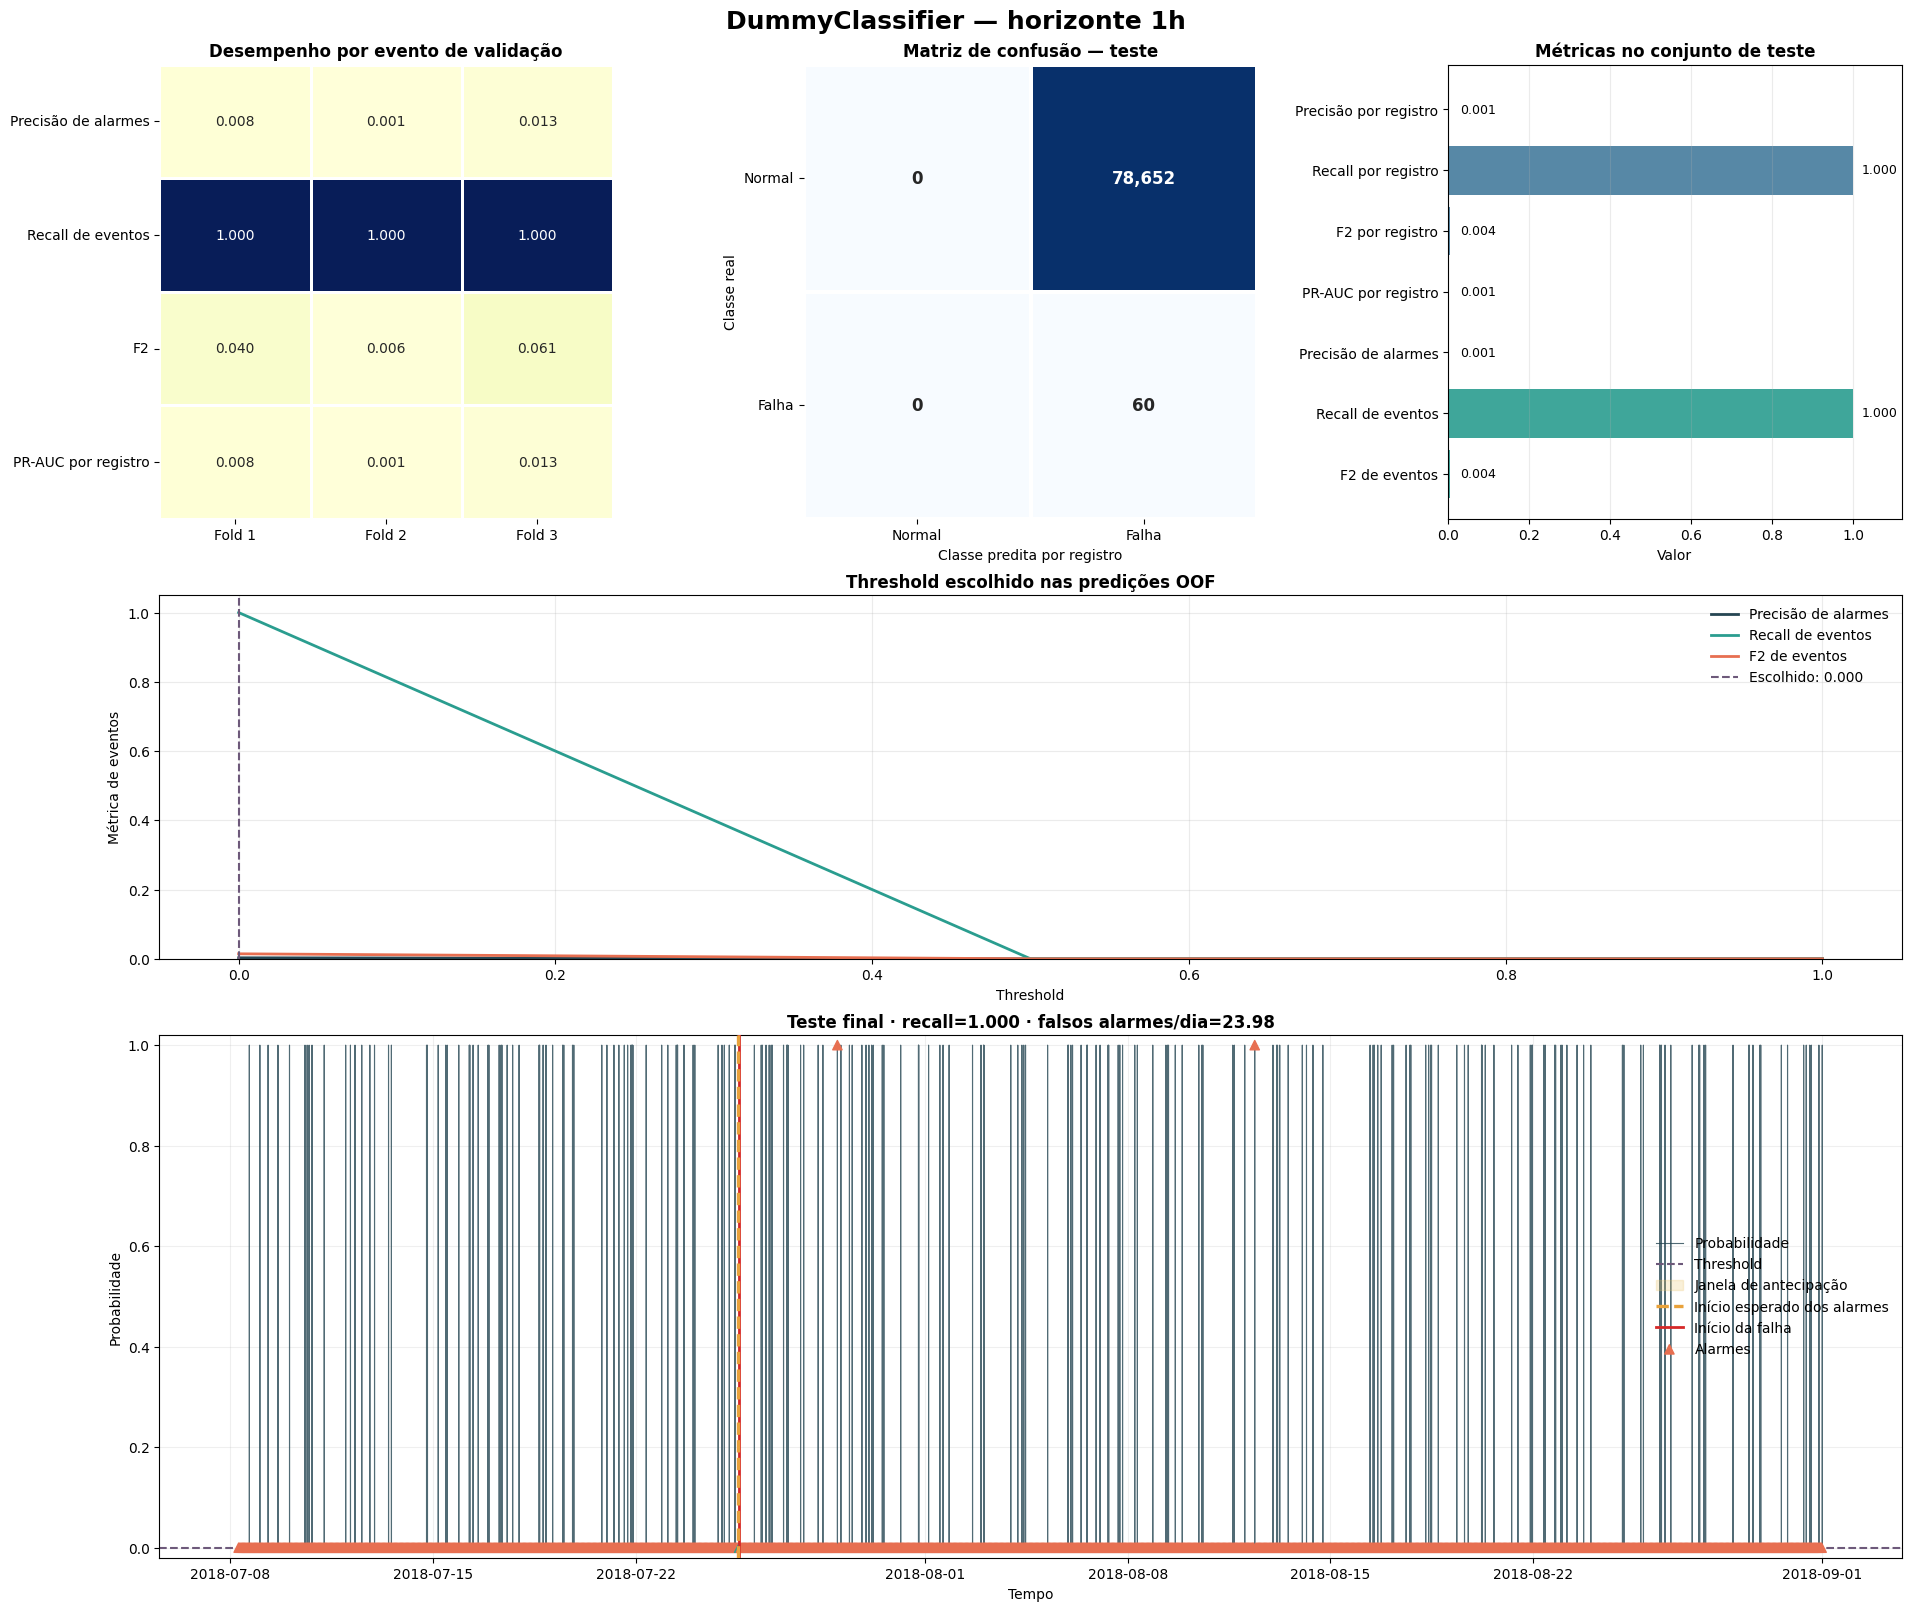

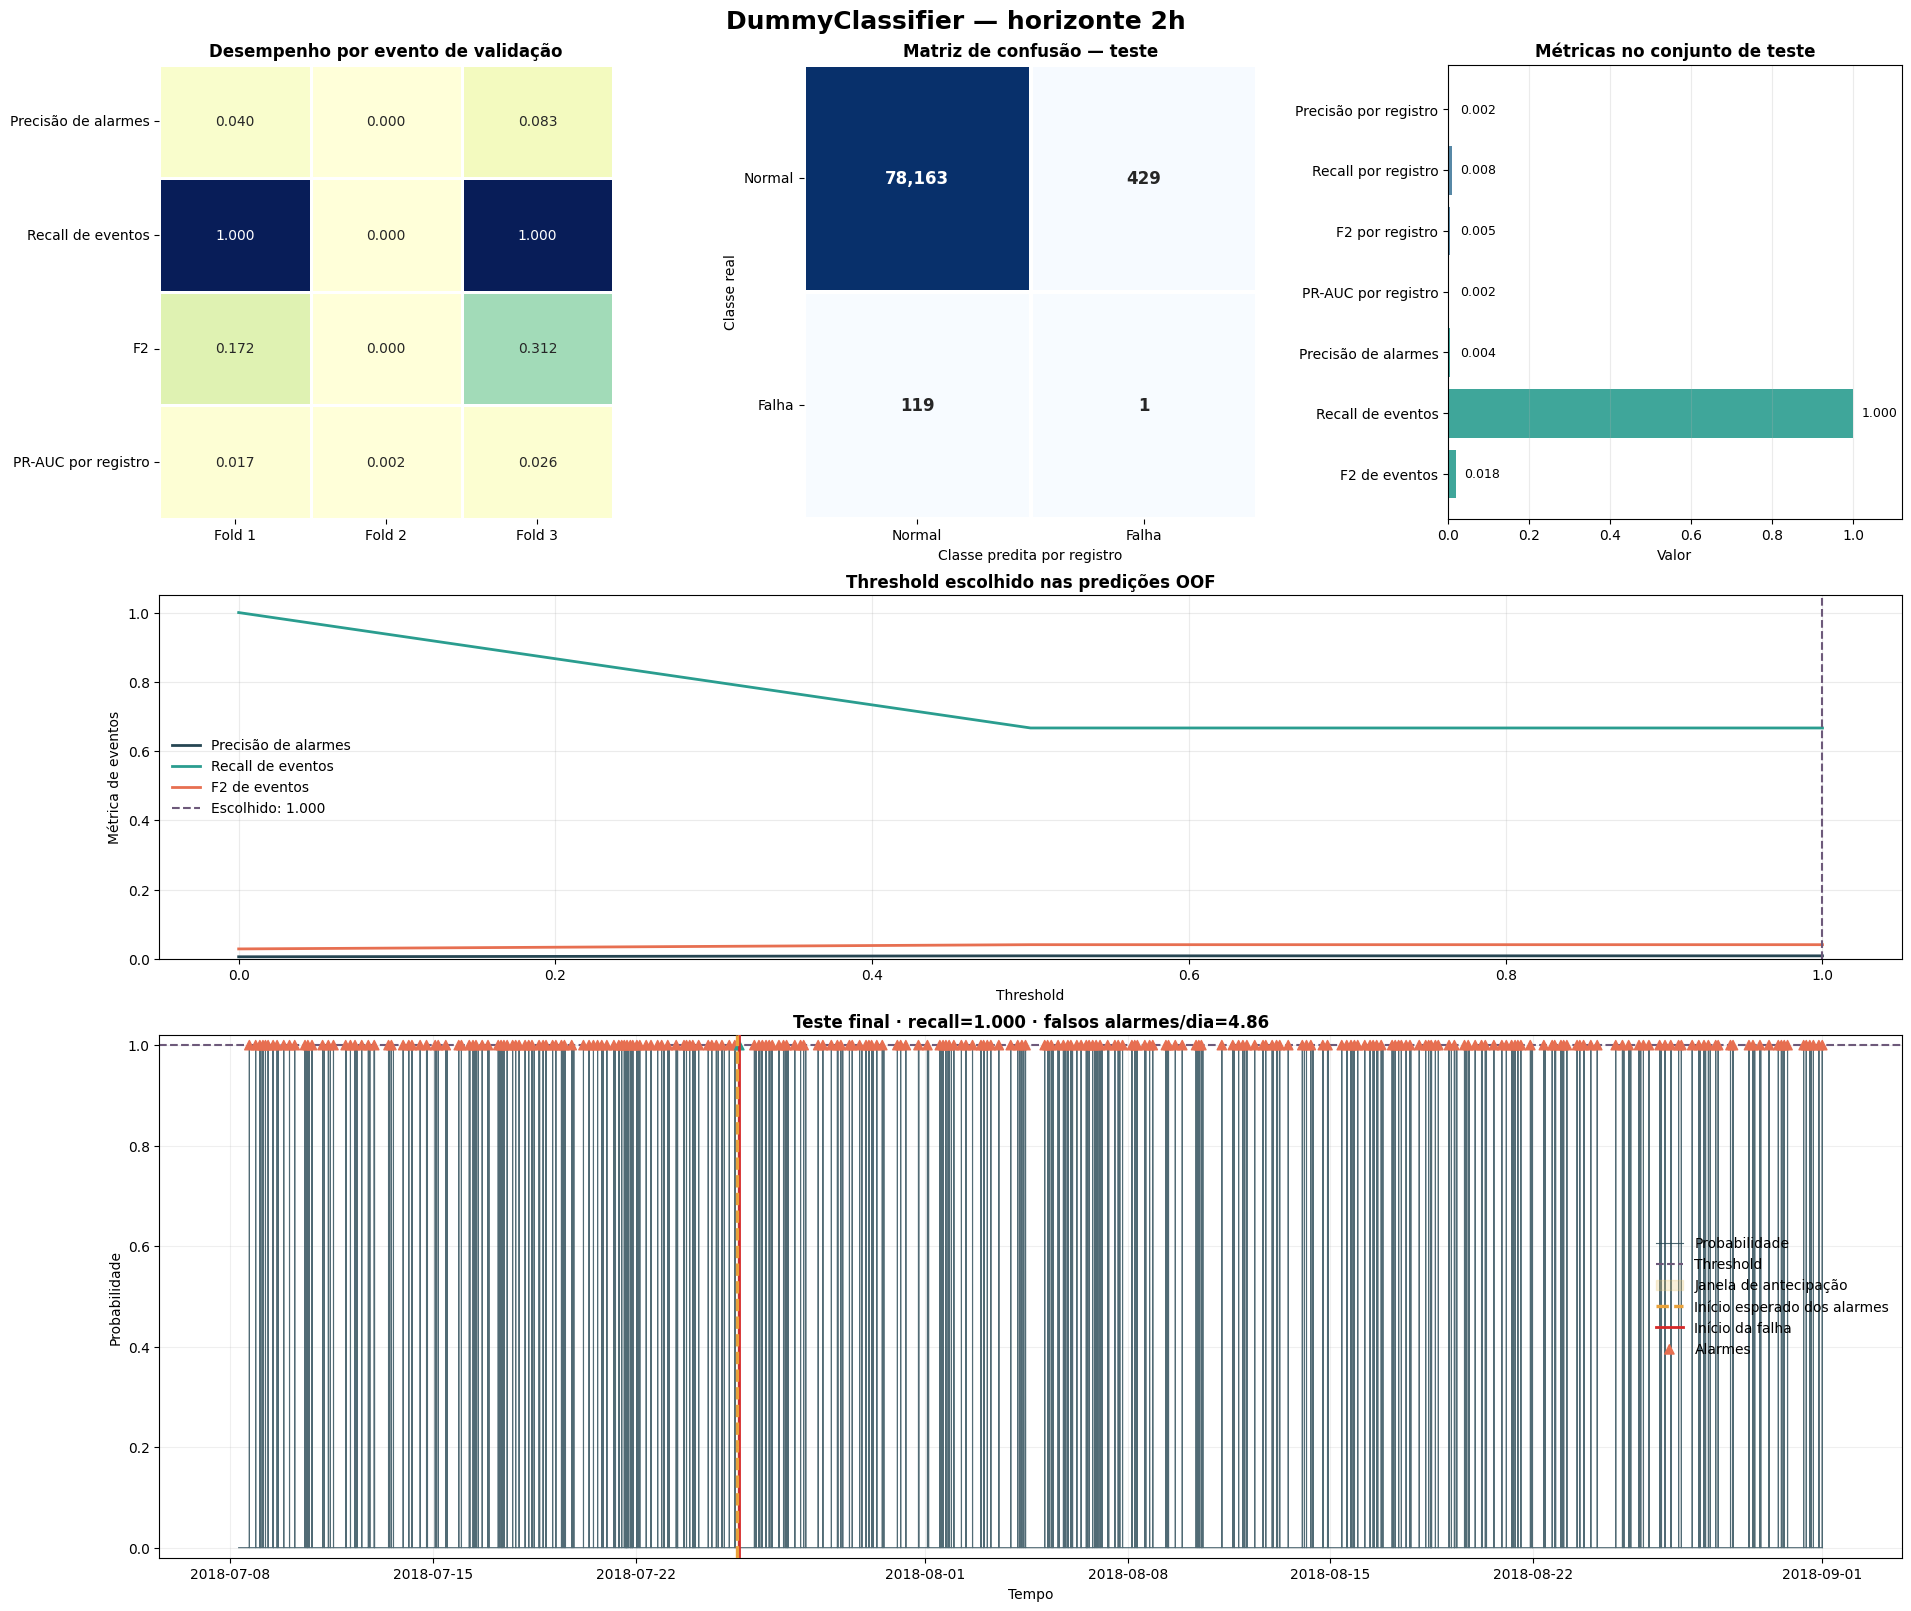

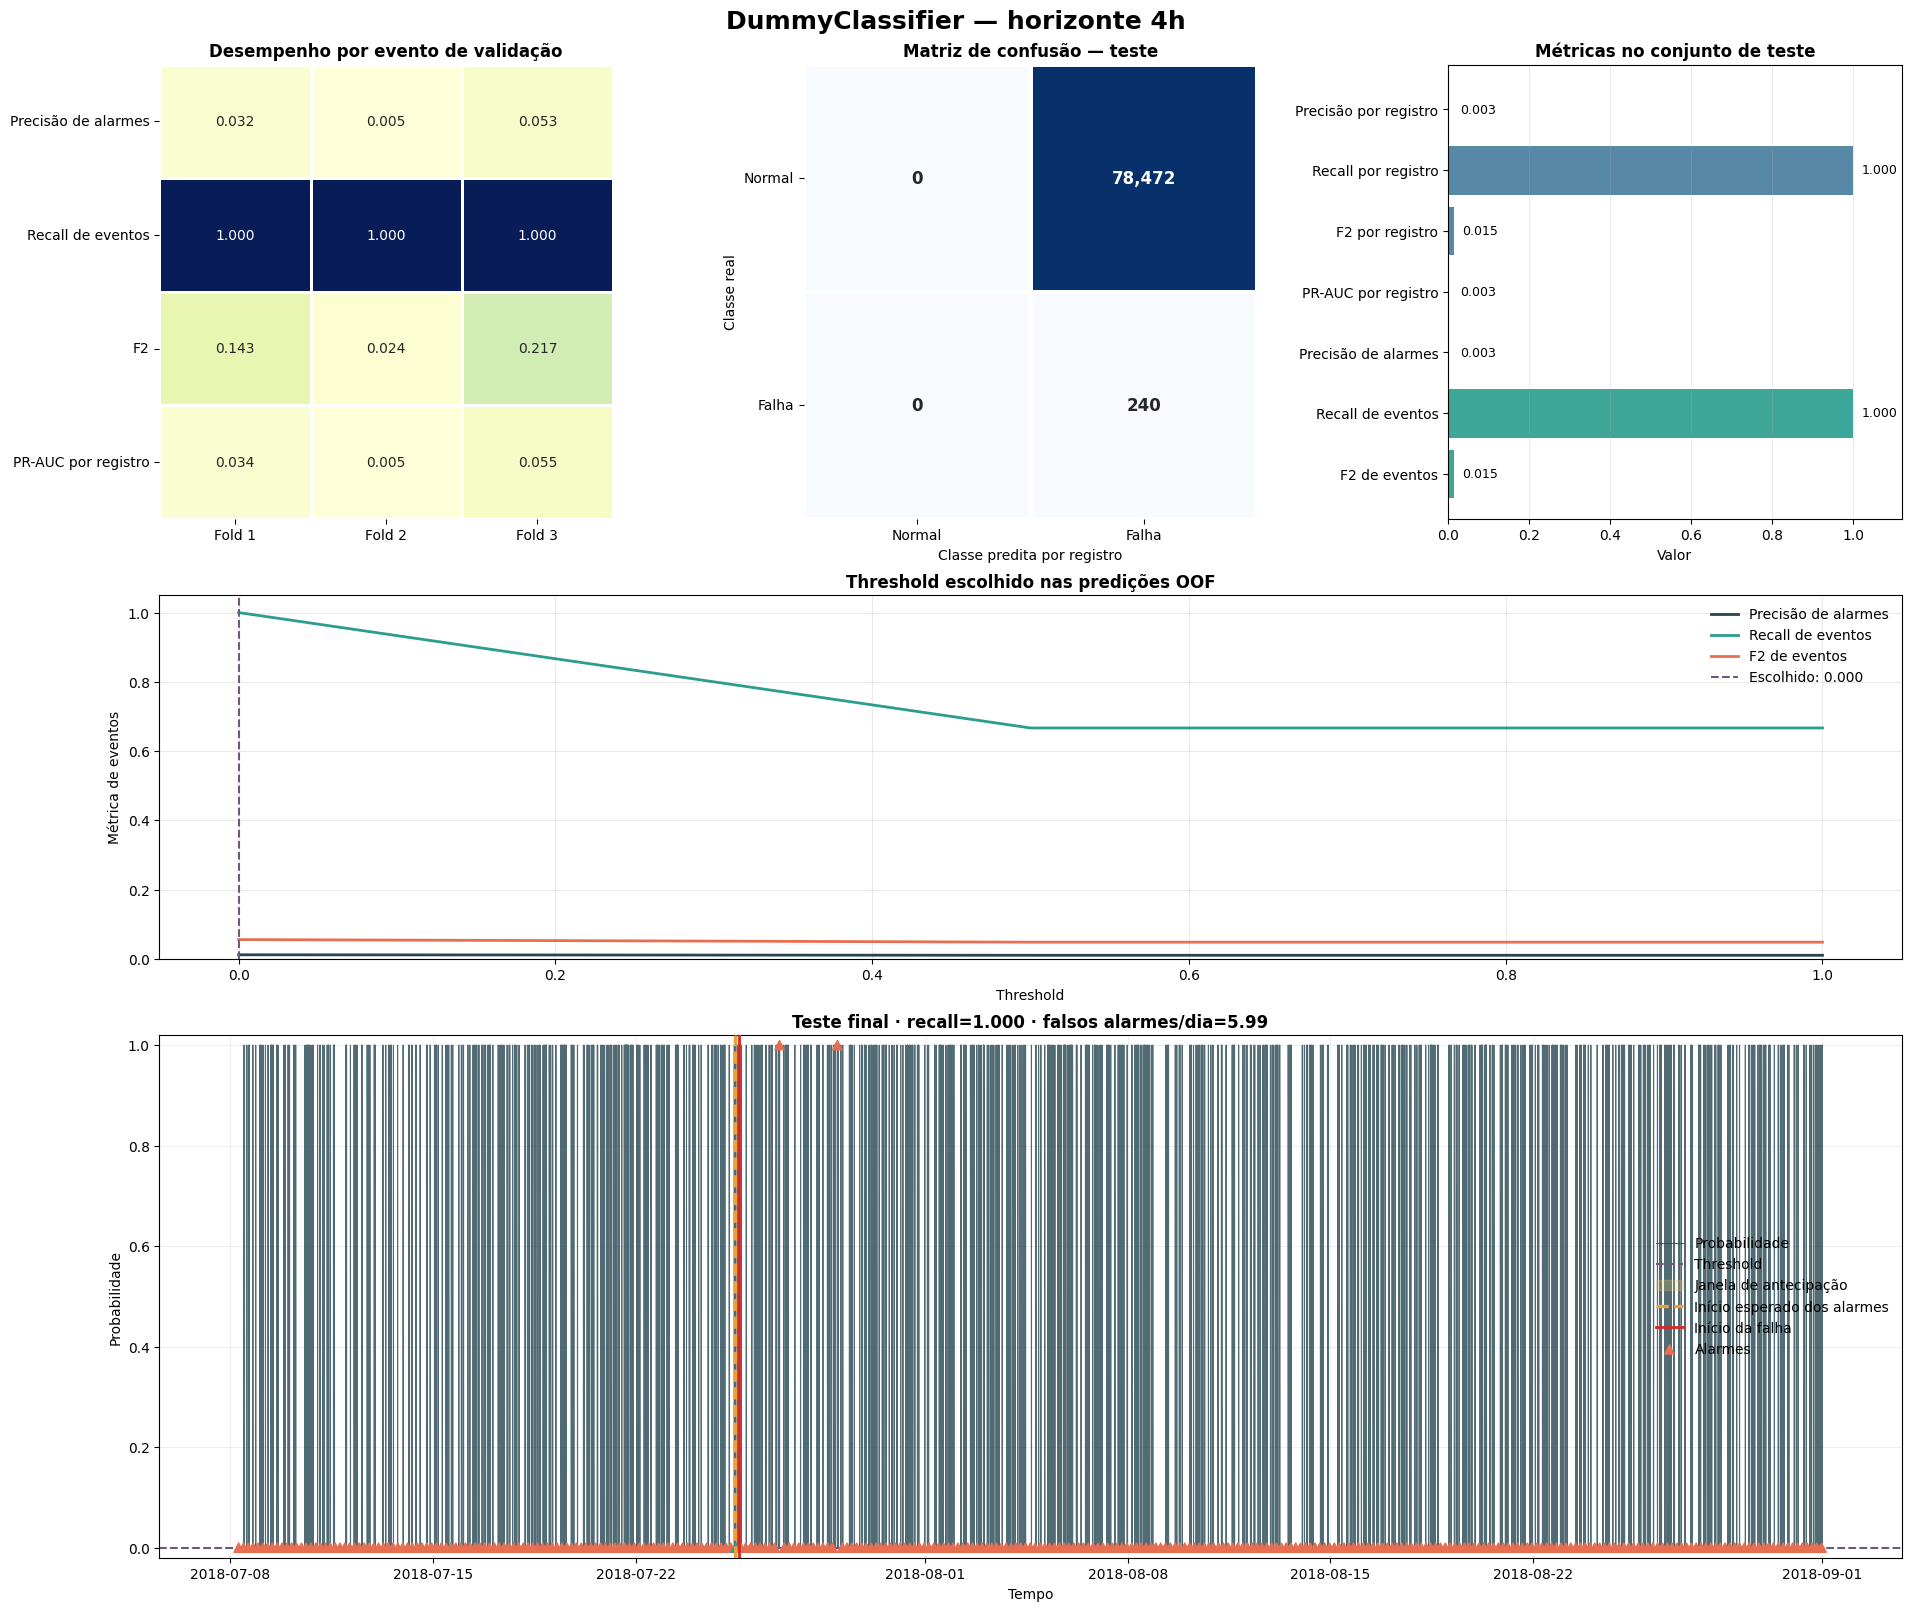

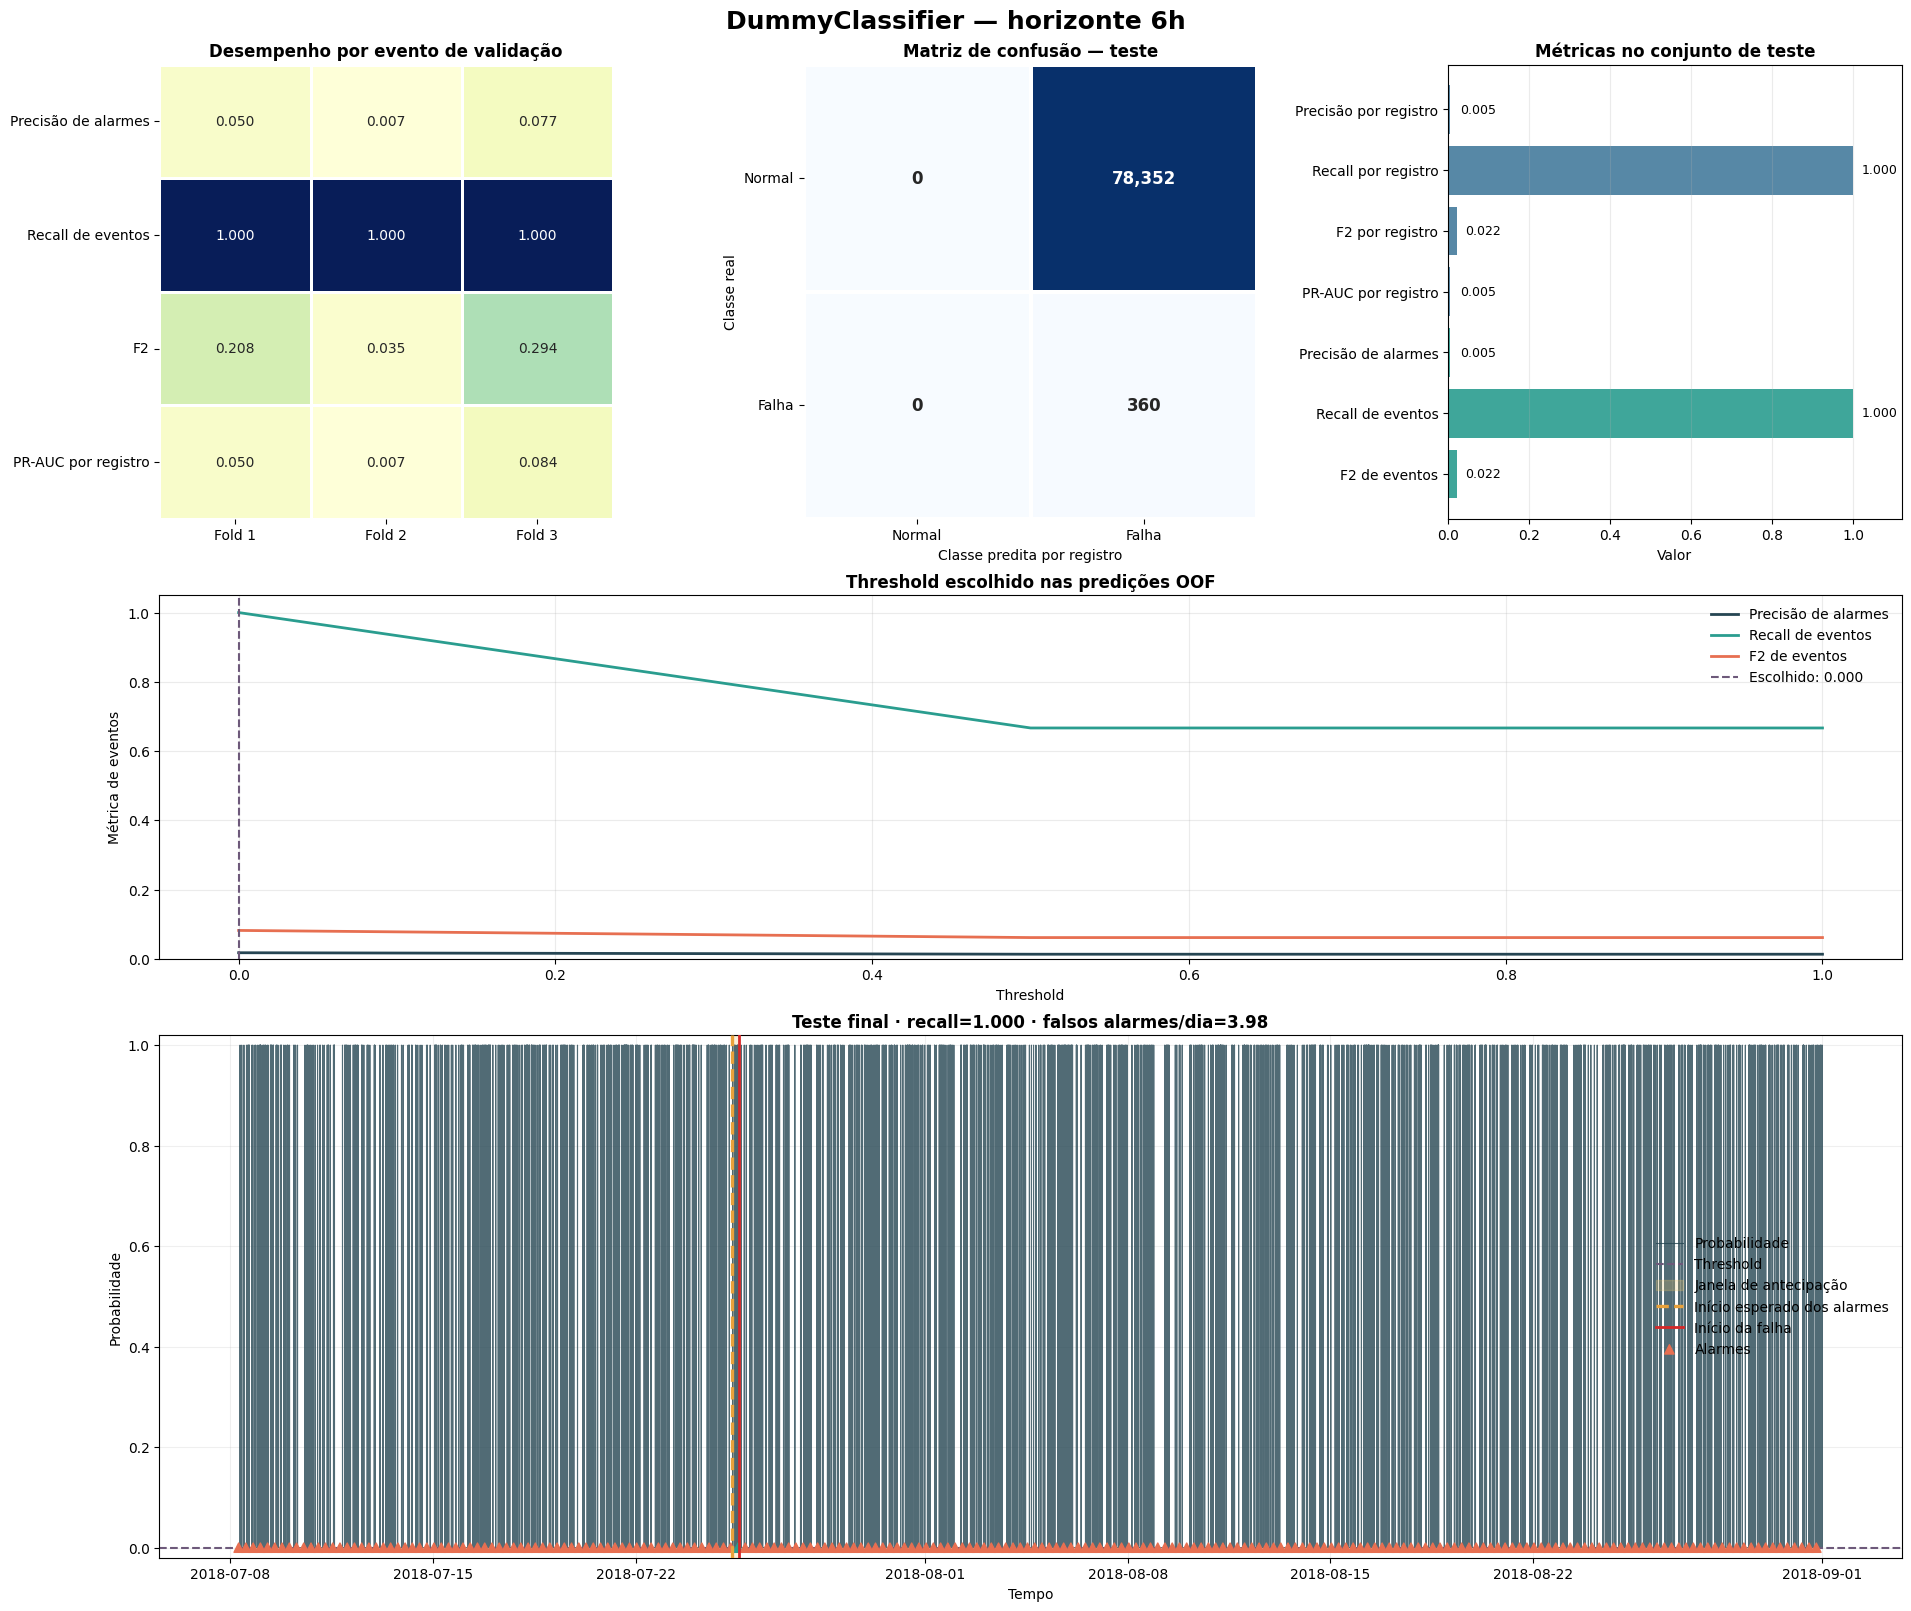

In [14]:
for label in sorted(resultados["DummyClassifier"], key=pd.Timedelta):
    resultado = resultados["DummyClassifier"][label]
    print(f"Resultados para {label}:")

    plotar_resultados_modelo(resultado, label)

### LogisticRegression

Resultados para 1h:
Resultados para 2h:
Resultados para 4h:
Resultados para 6h:


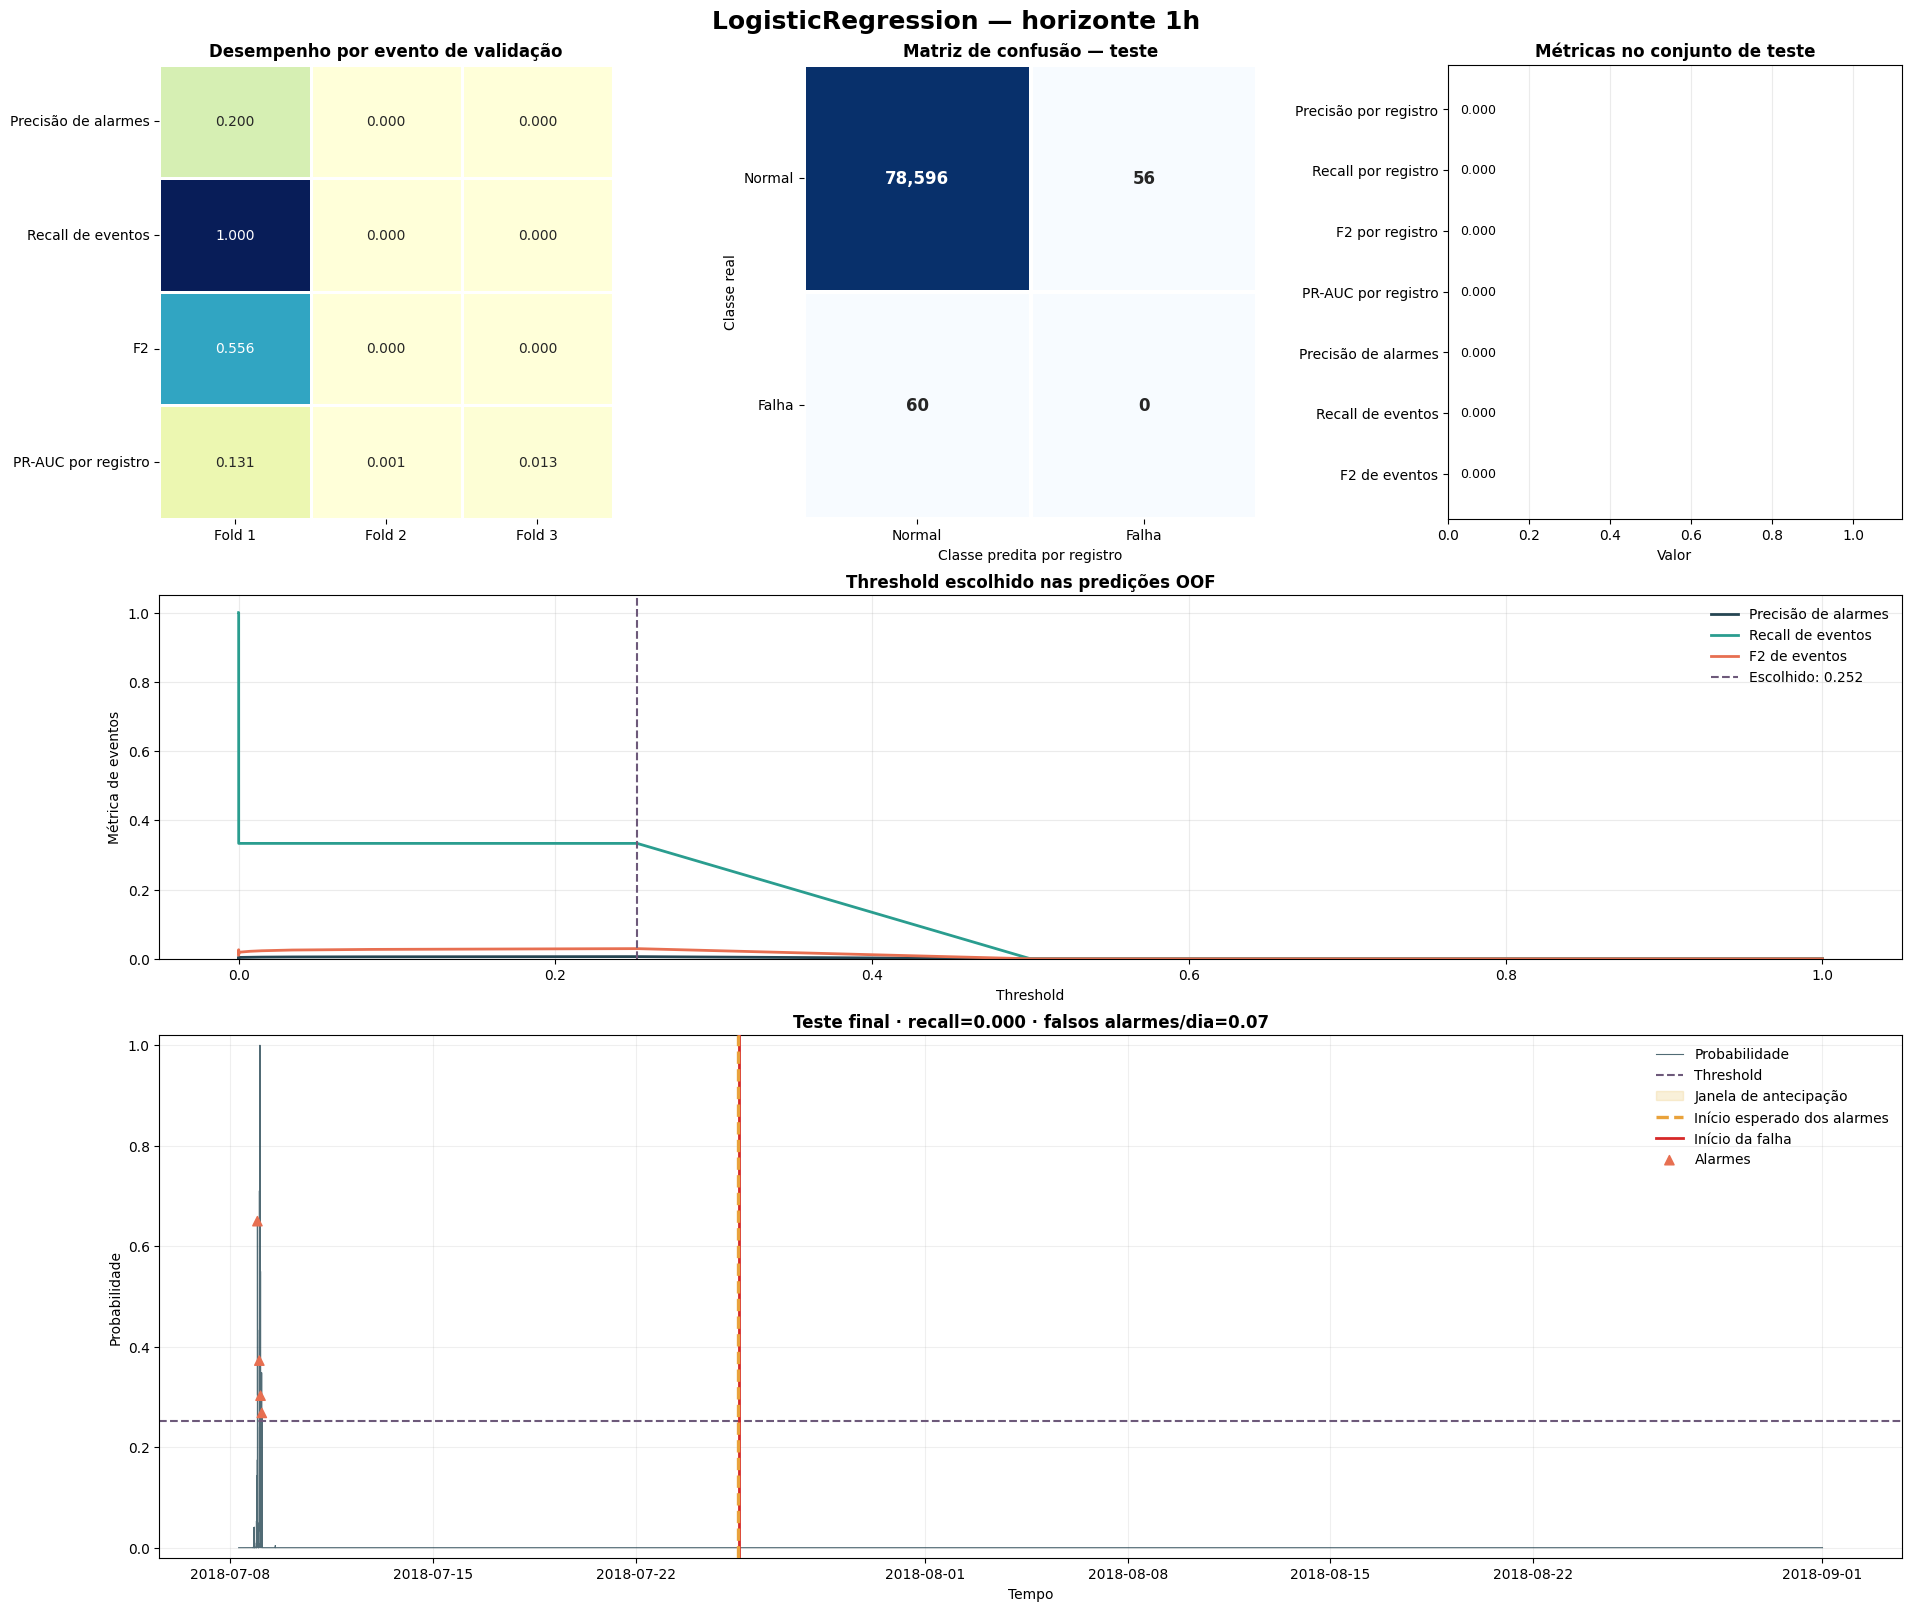

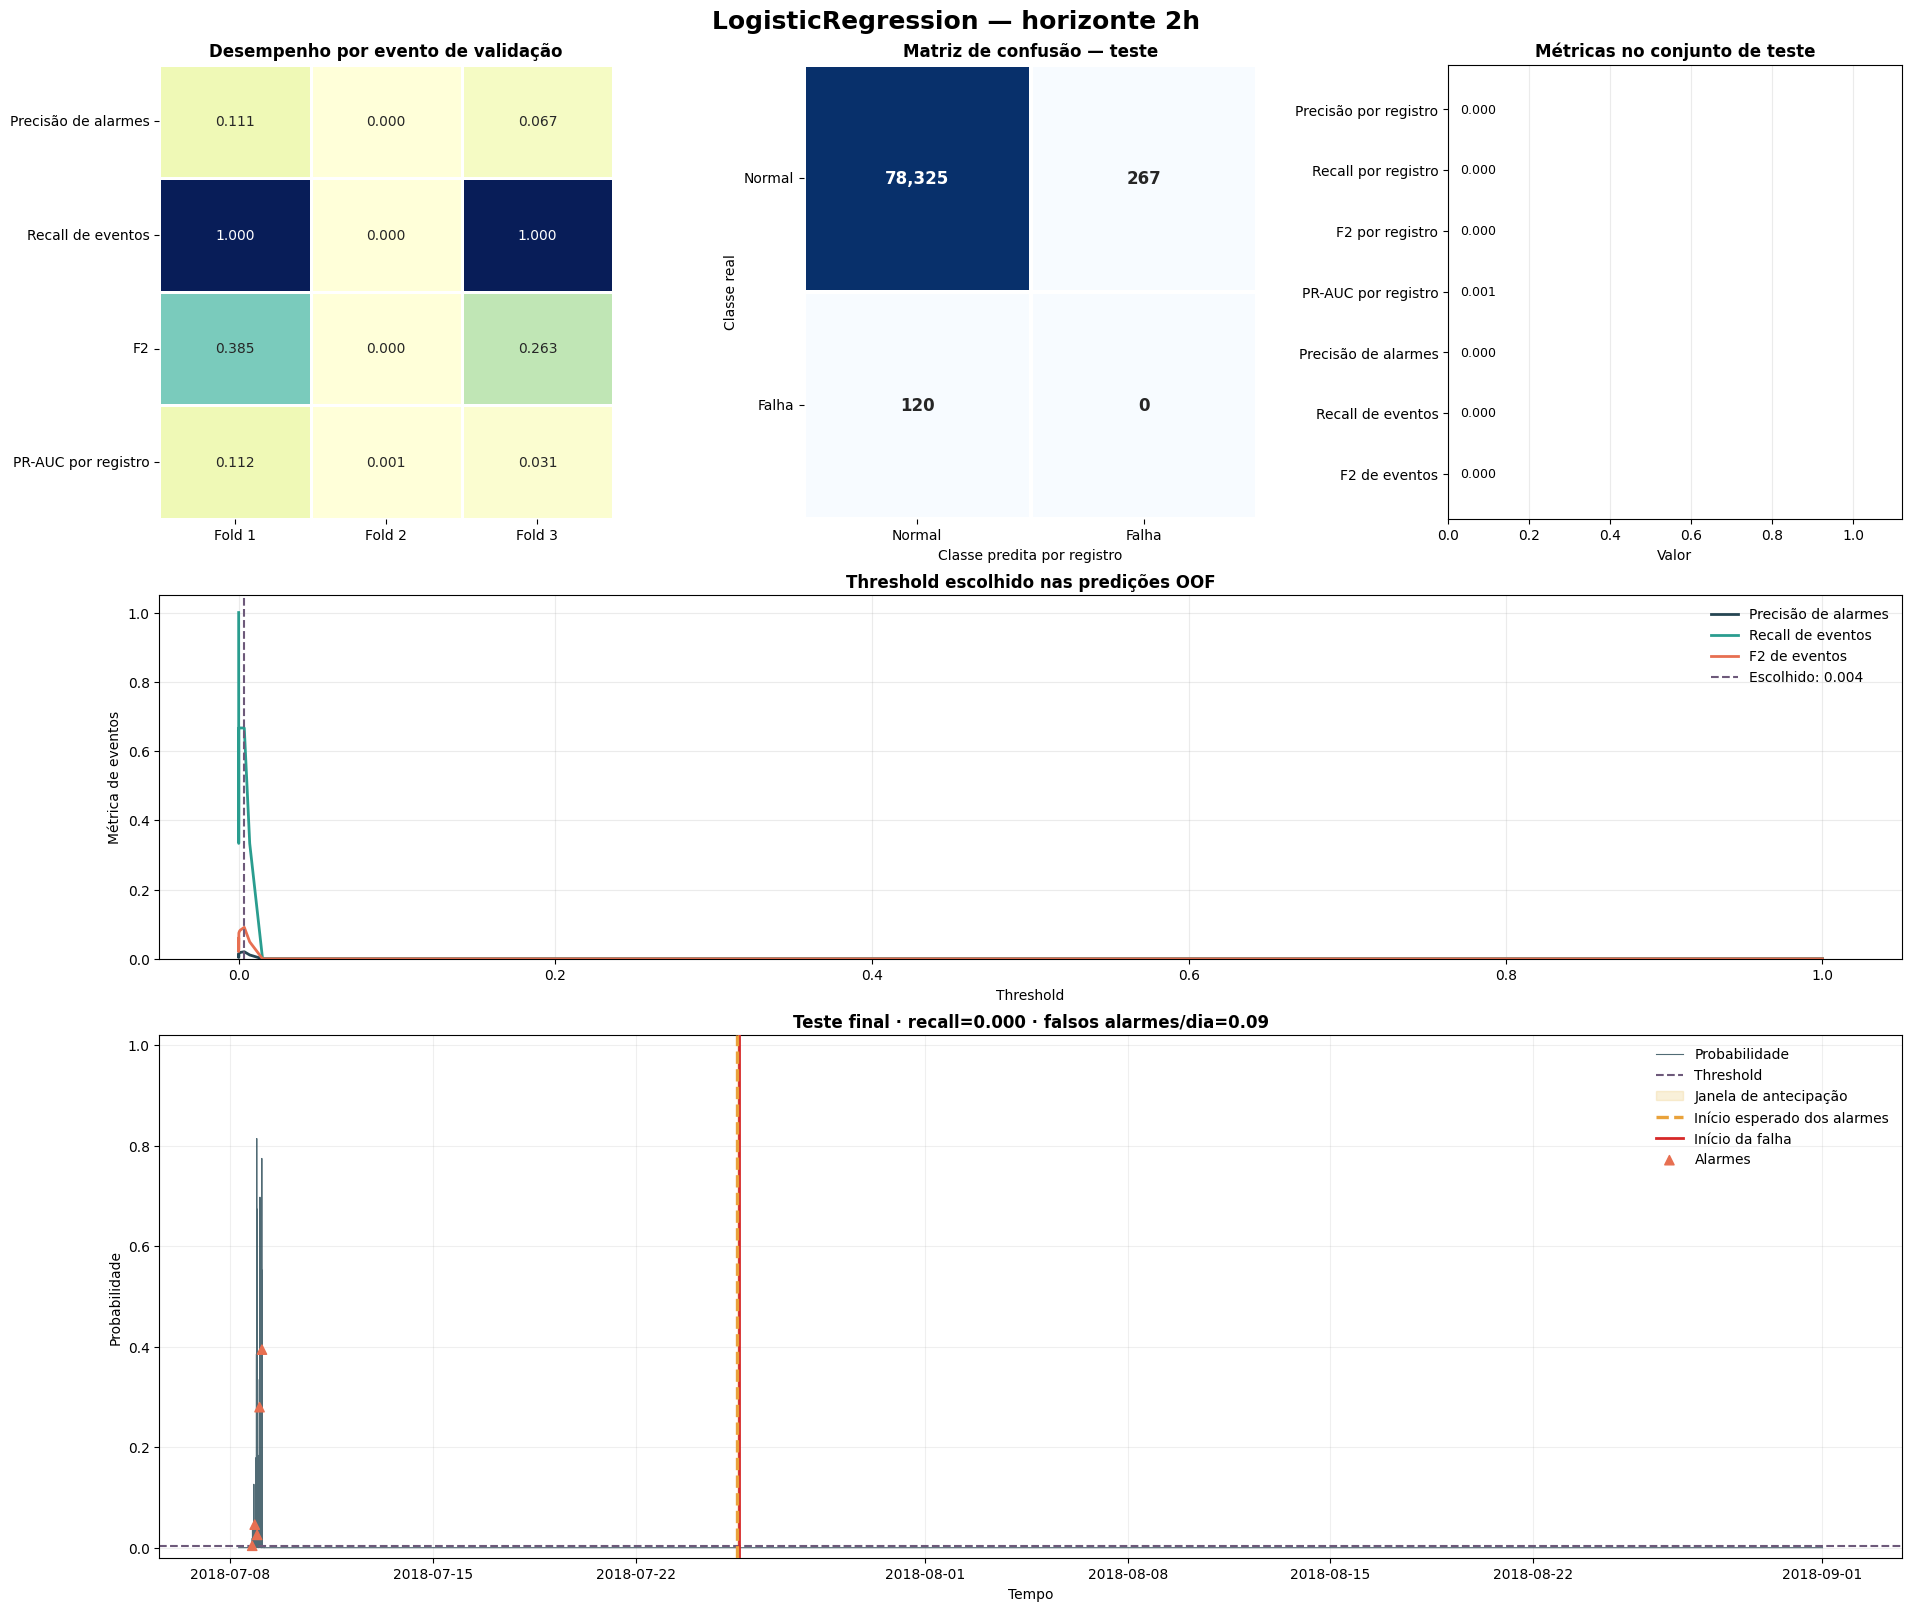

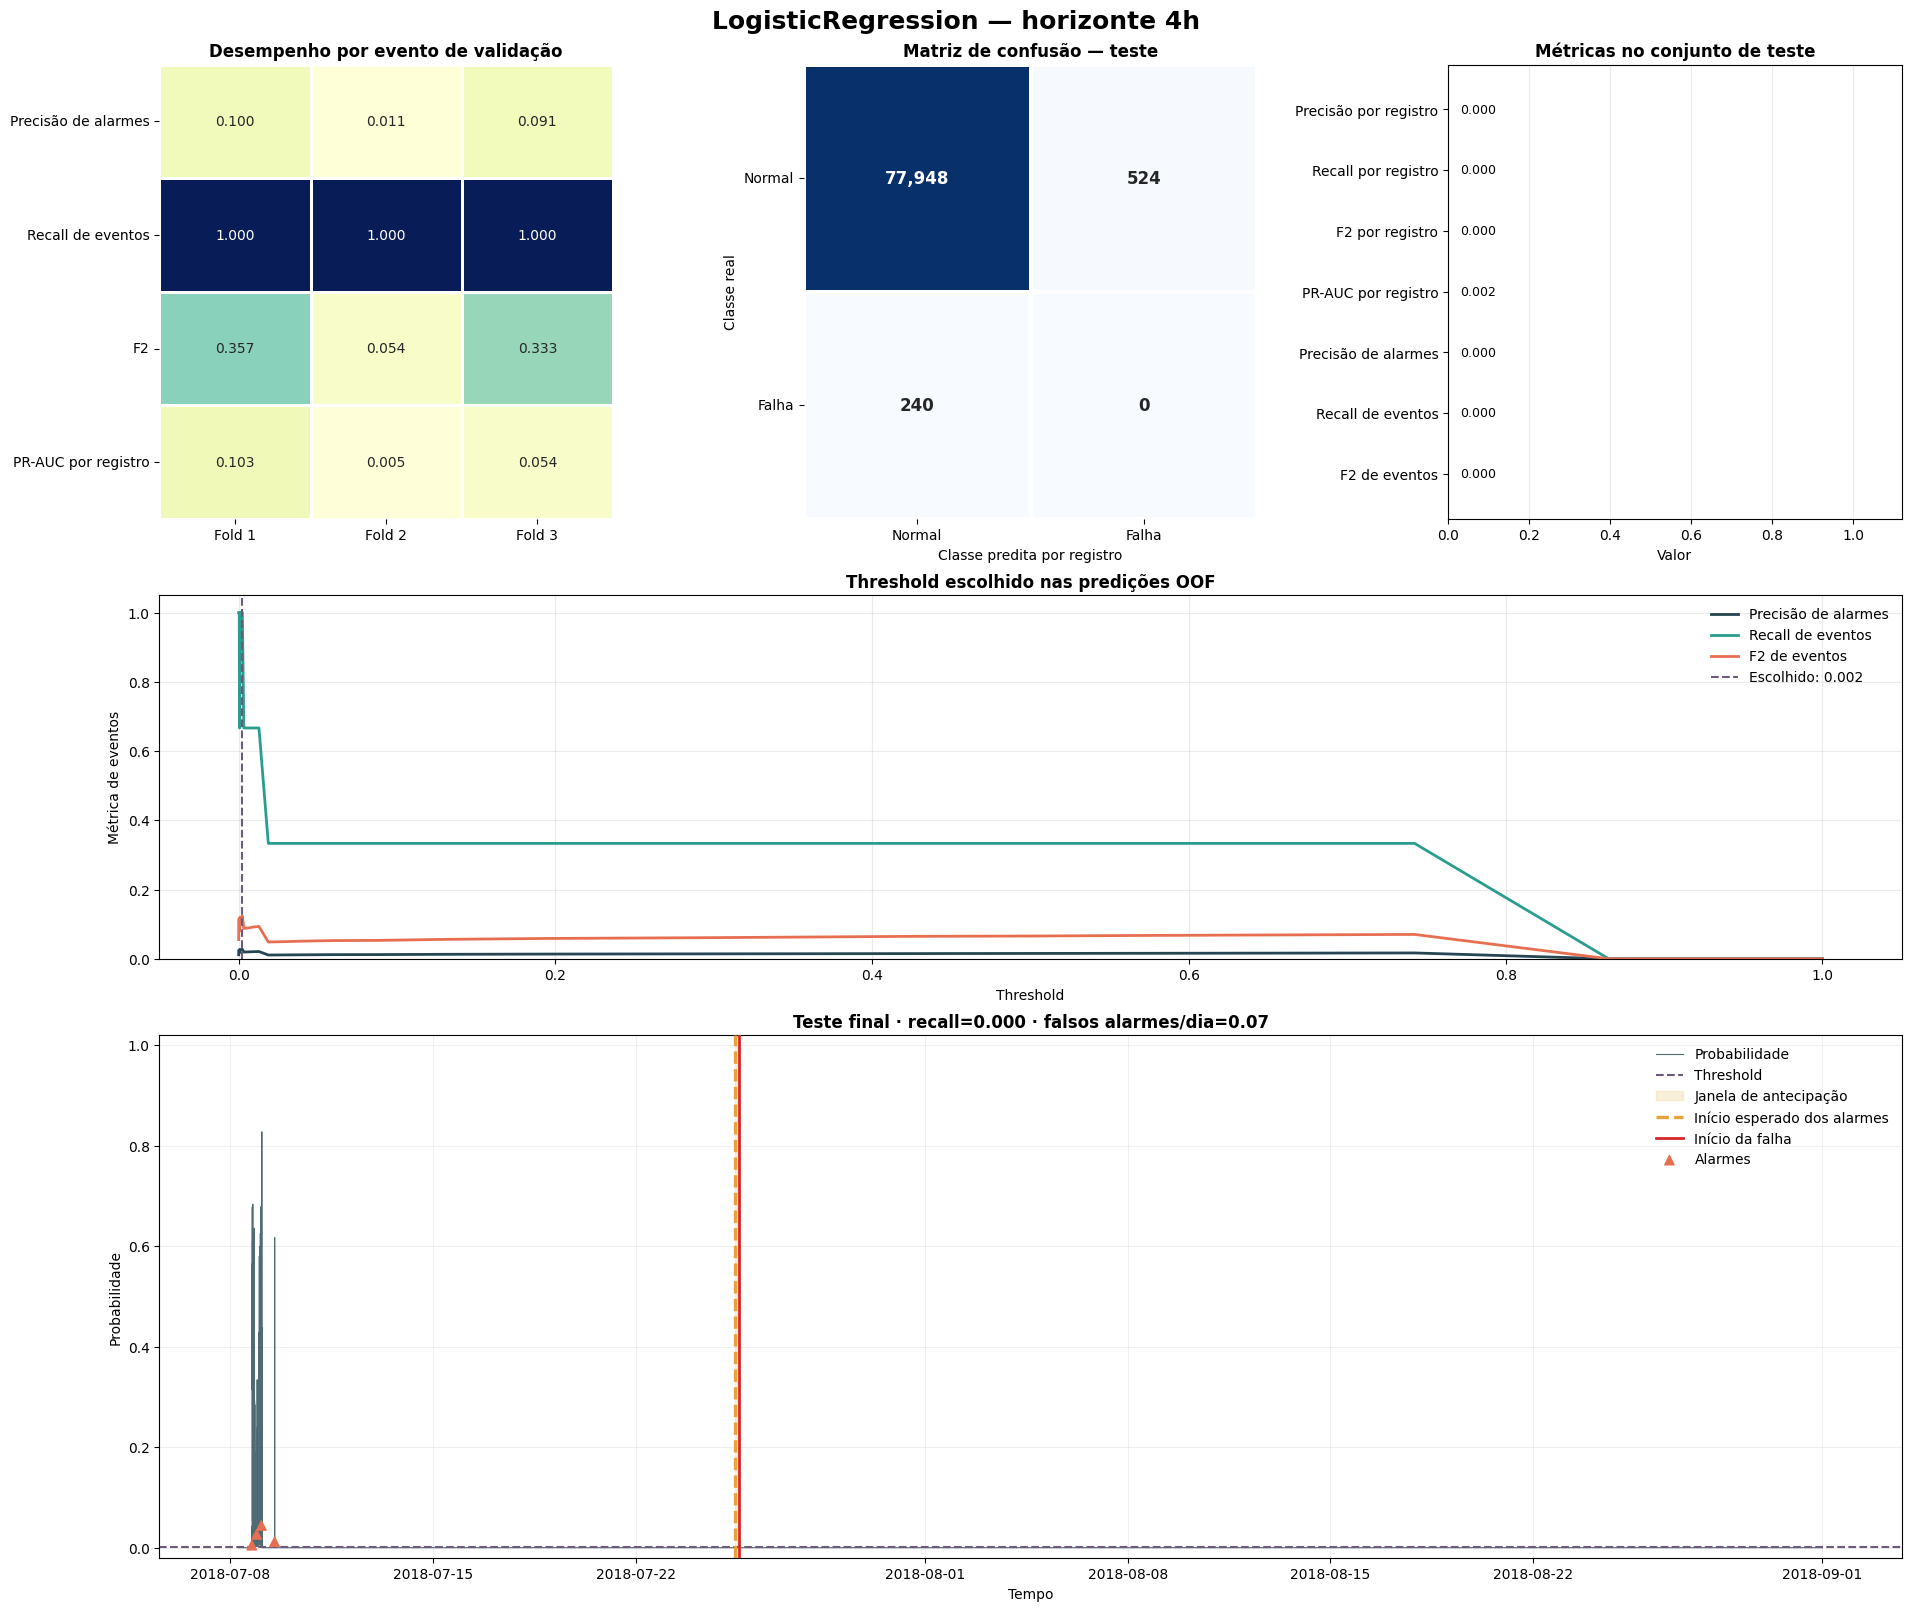

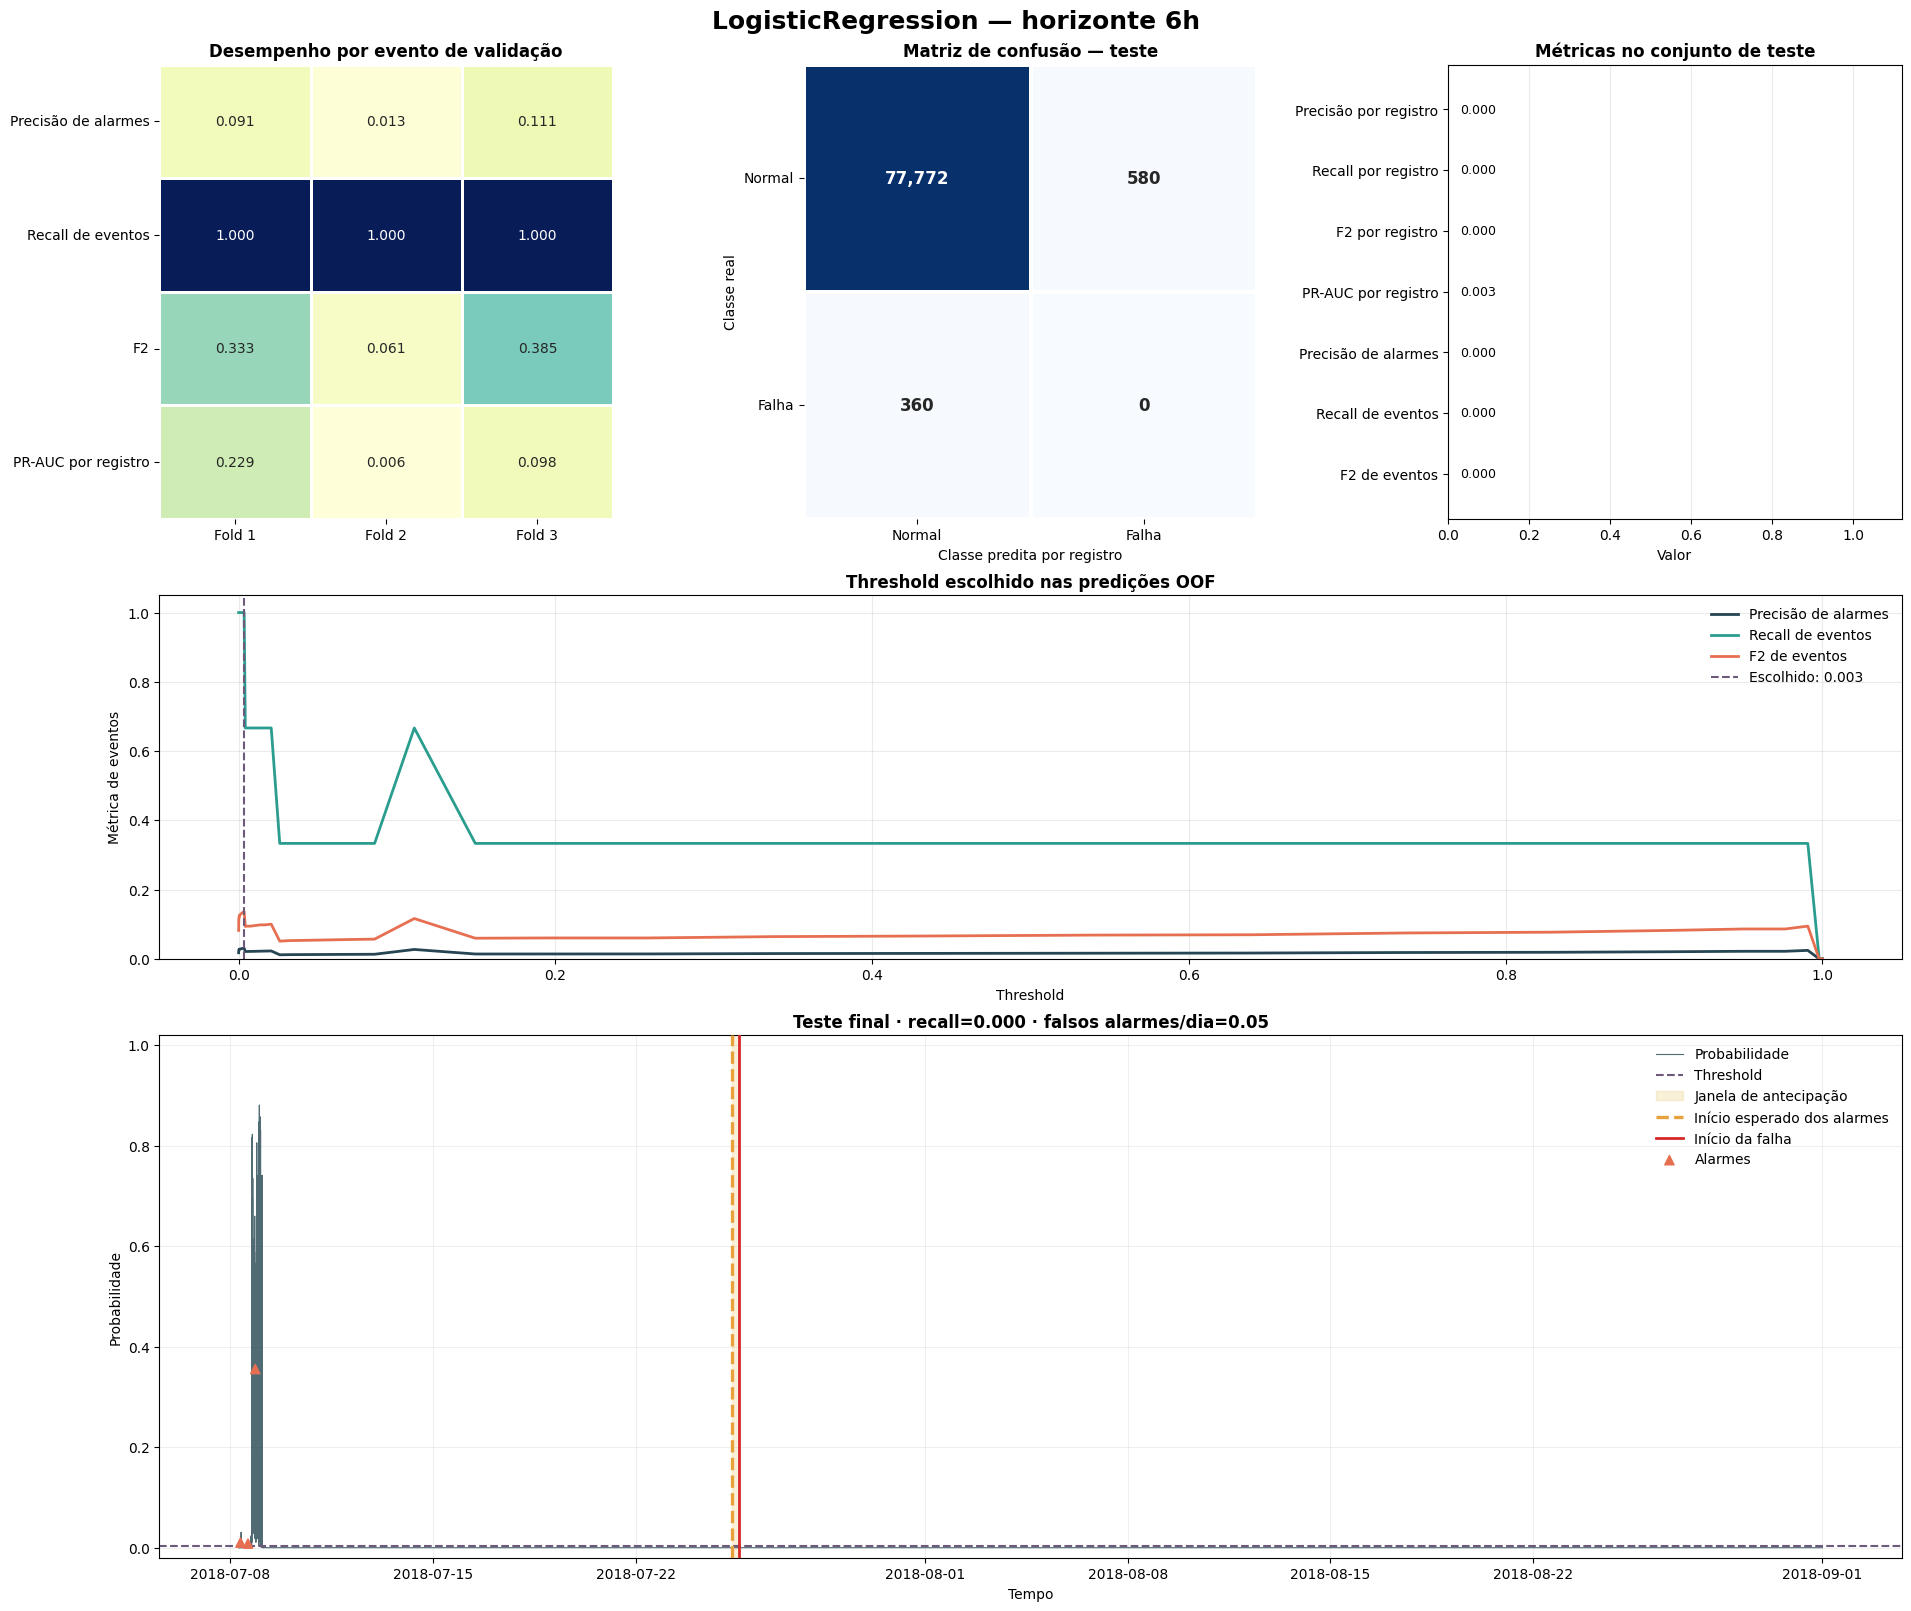

In [15]:
for label in sorted(resultados["LogisticRegression"], key=pd.Timedelta):
    resultado = resultados["LogisticRegression"][label]
    print(f"Resultados para {label}:")

    plotar_resultados_modelo(resultado, label)

### XGBoost

Resultados para 1h:
Resultados para 2h:
Resultados para 4h:
Resultados para 6h:


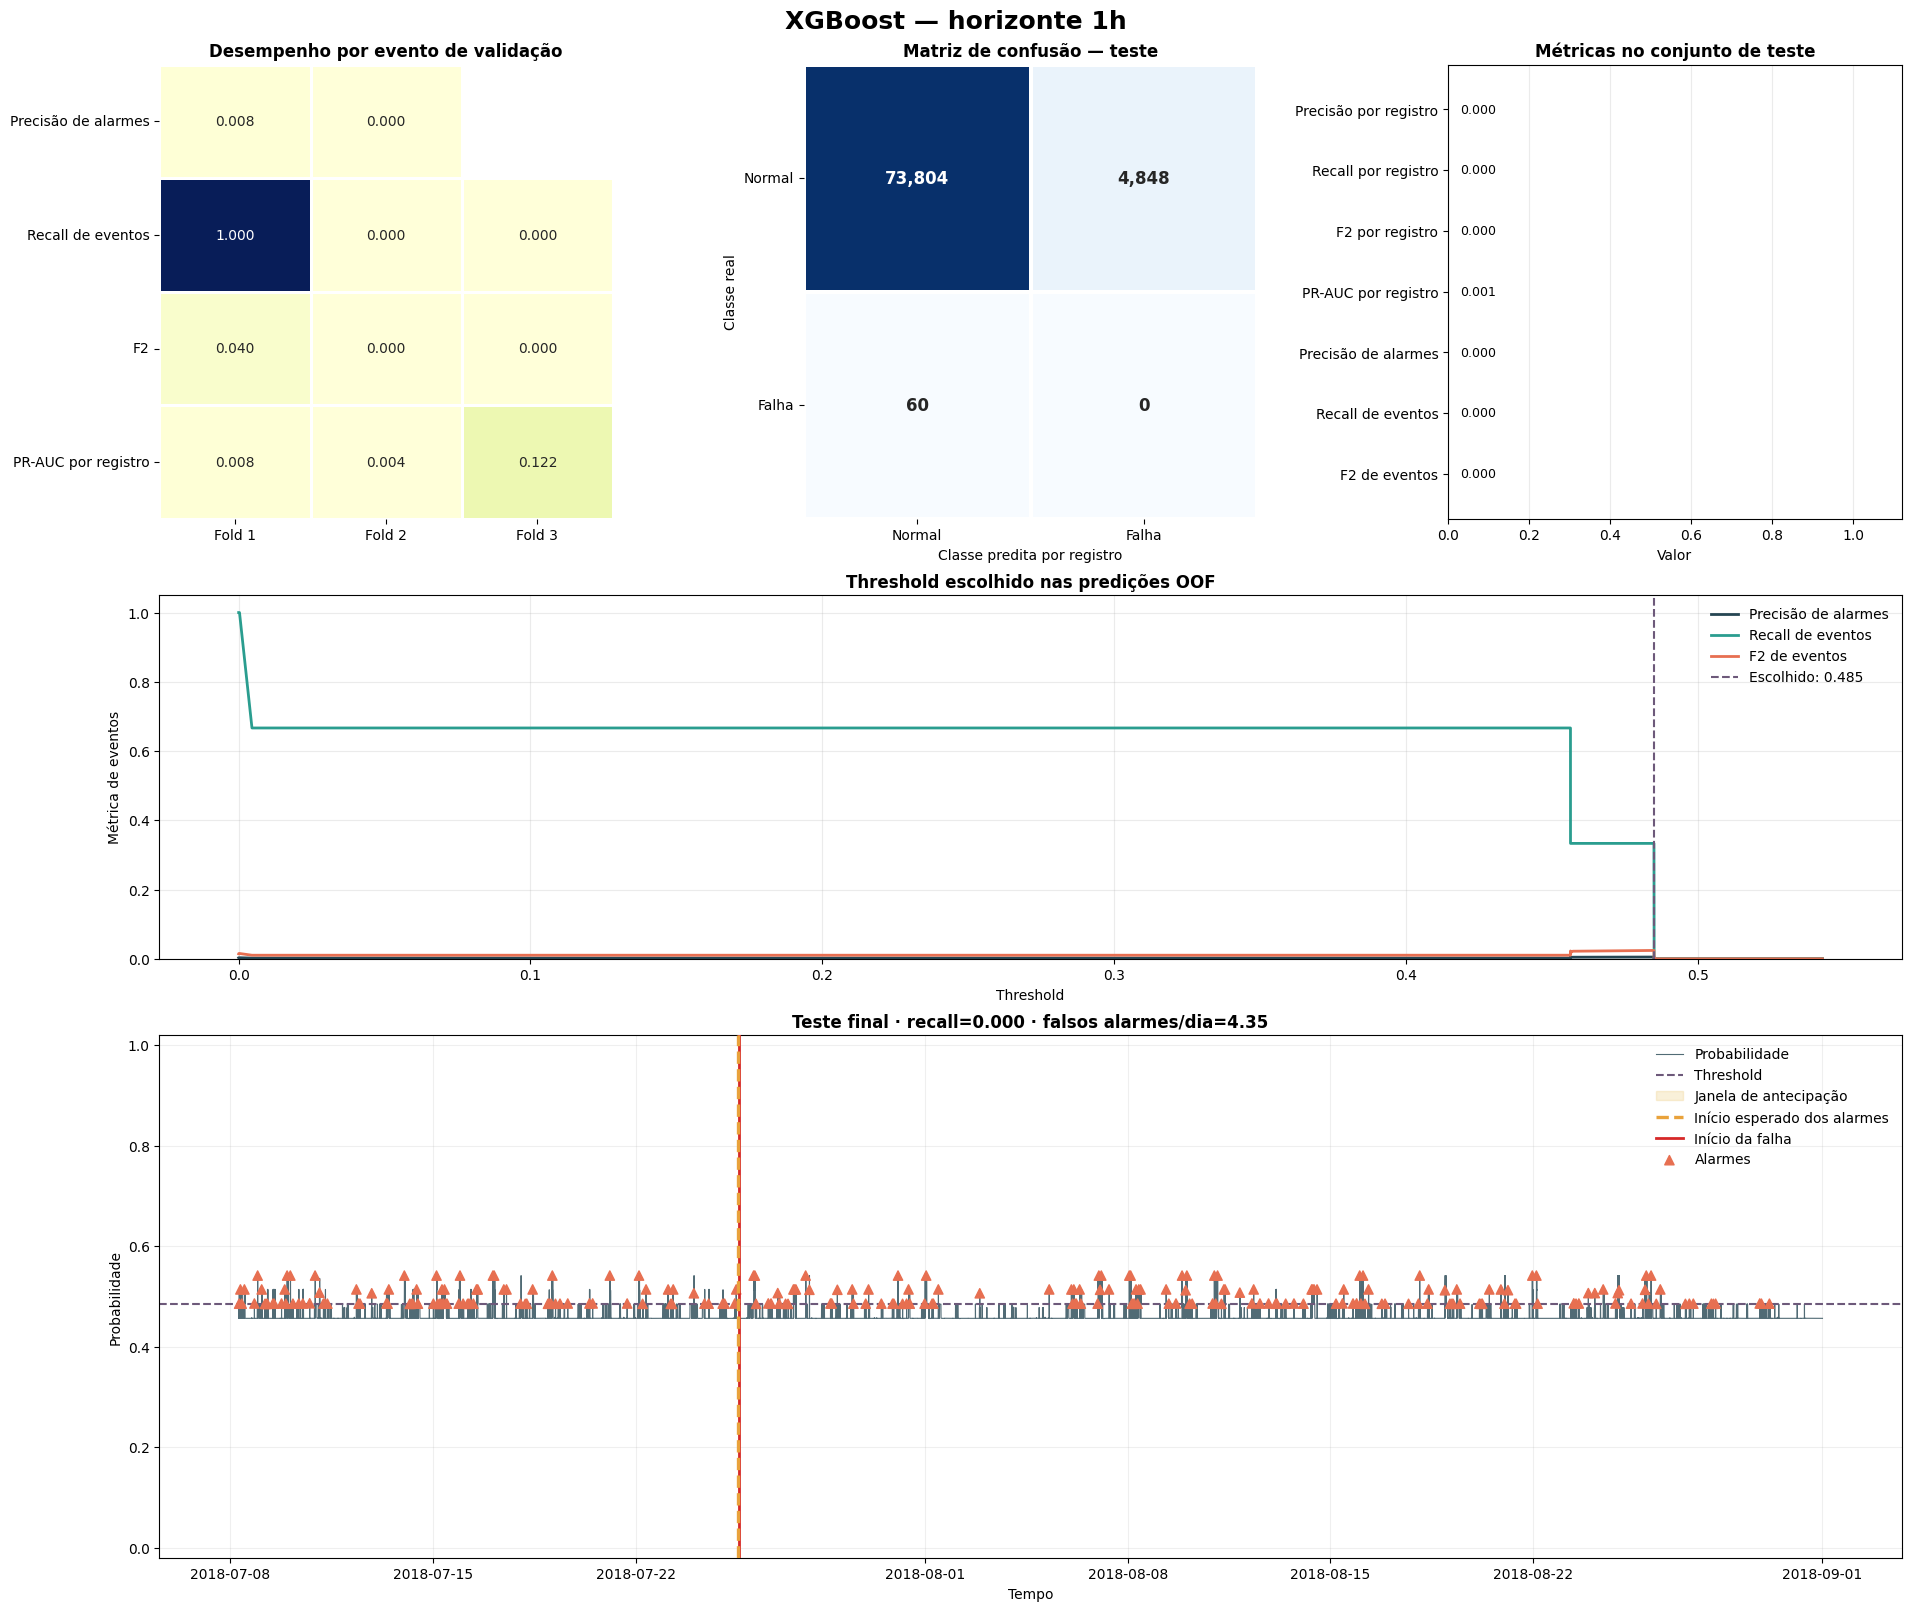

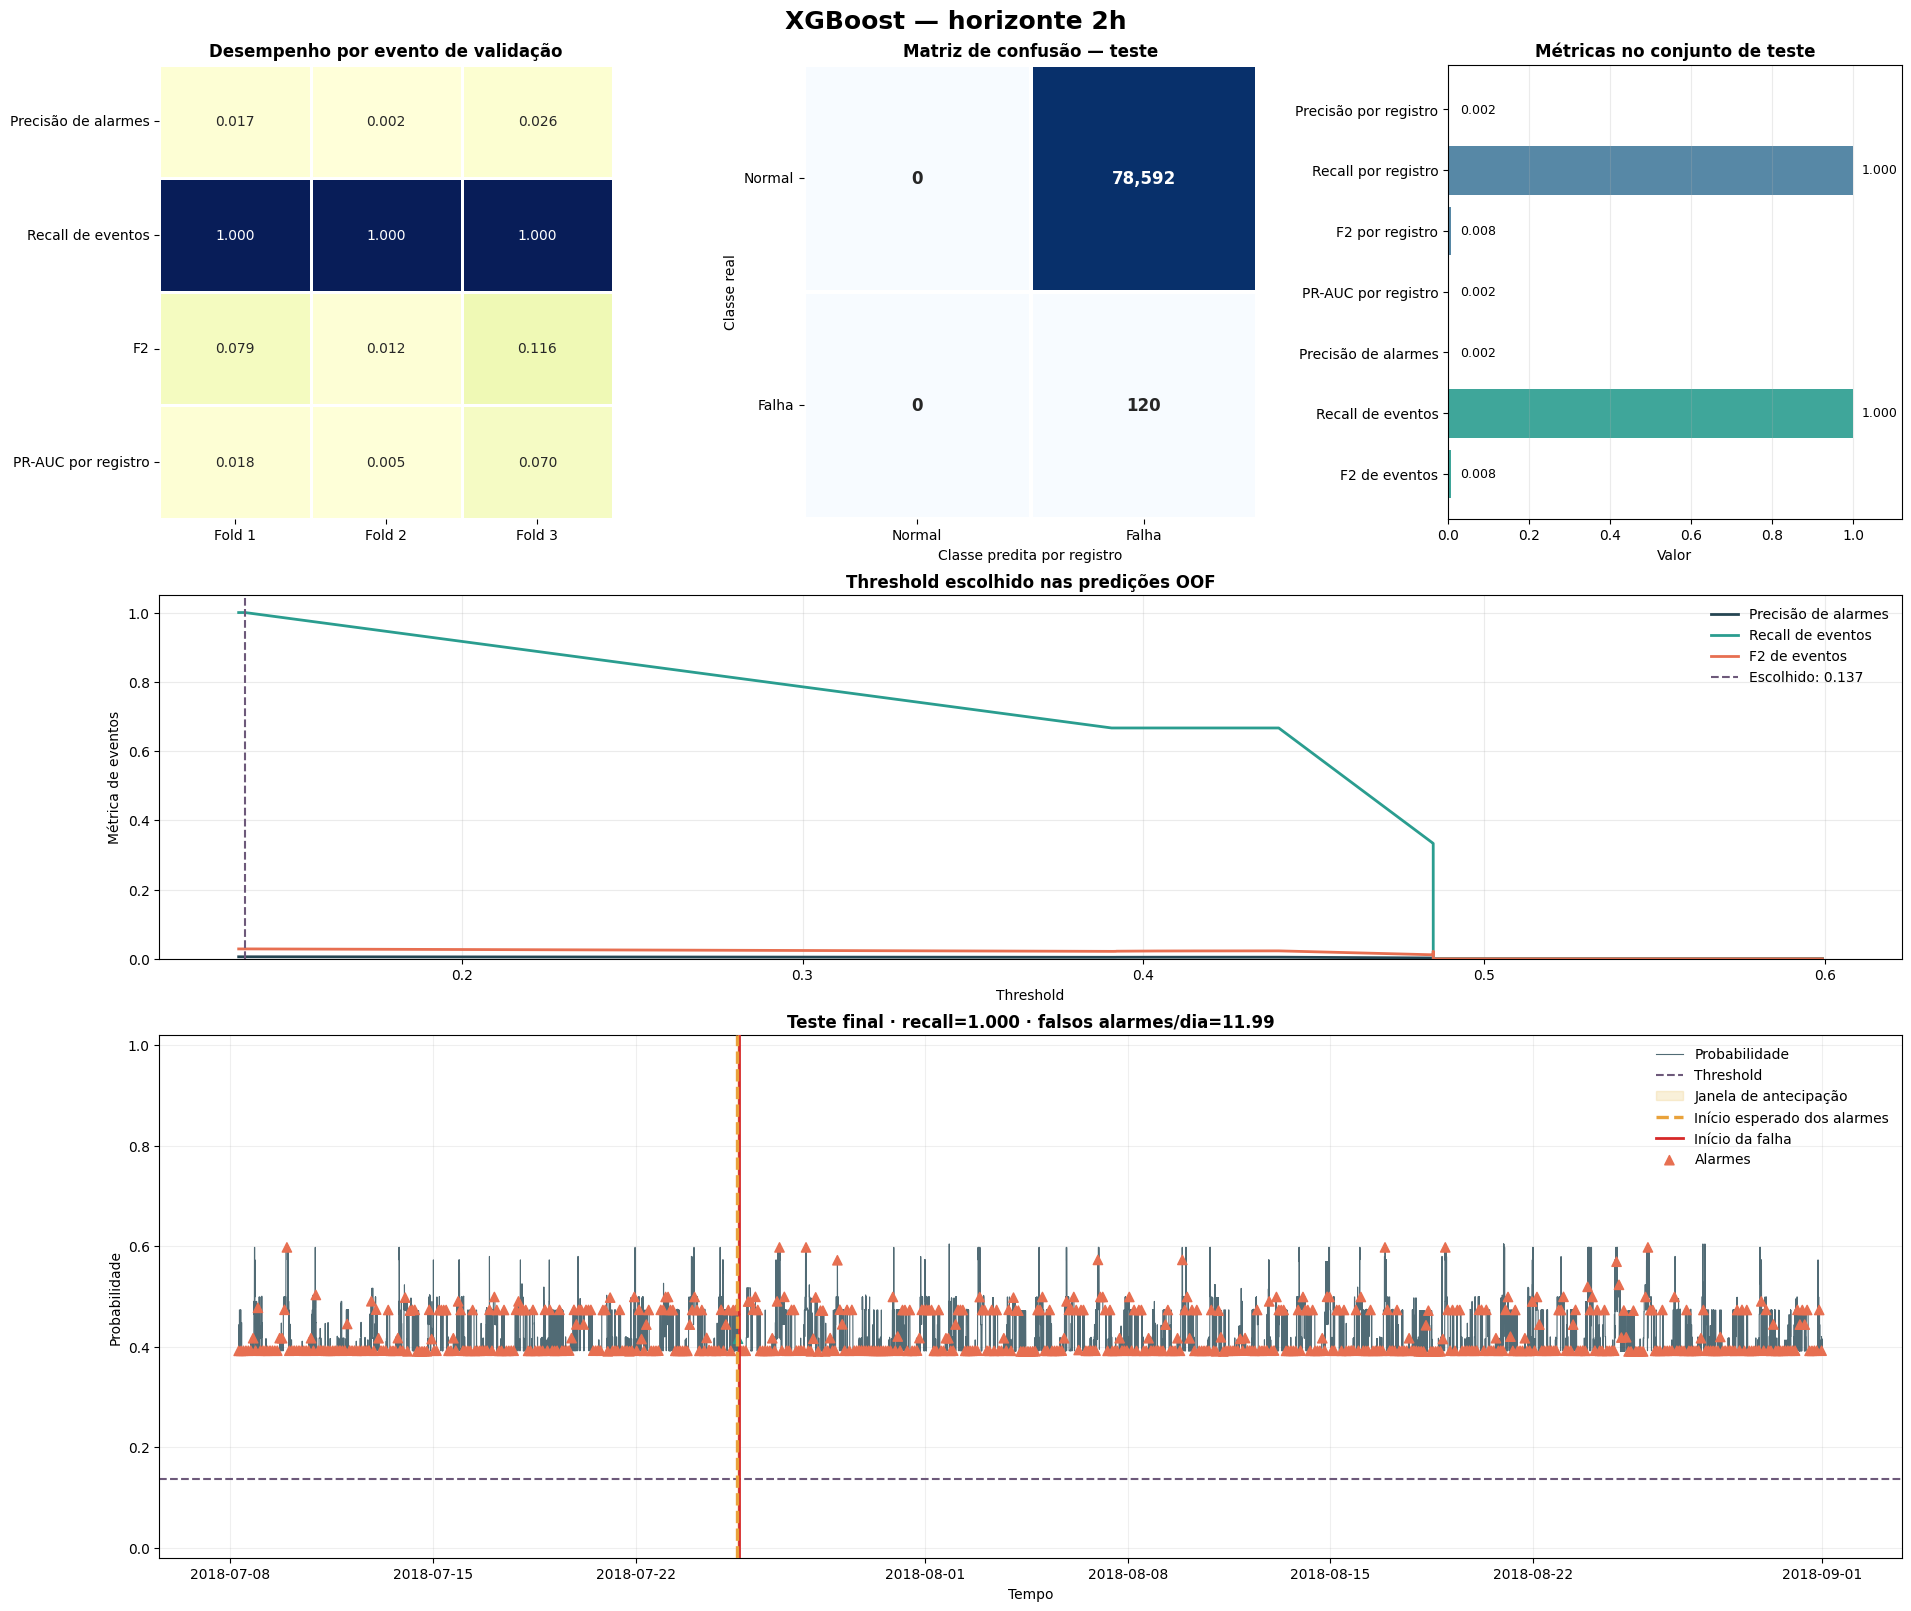

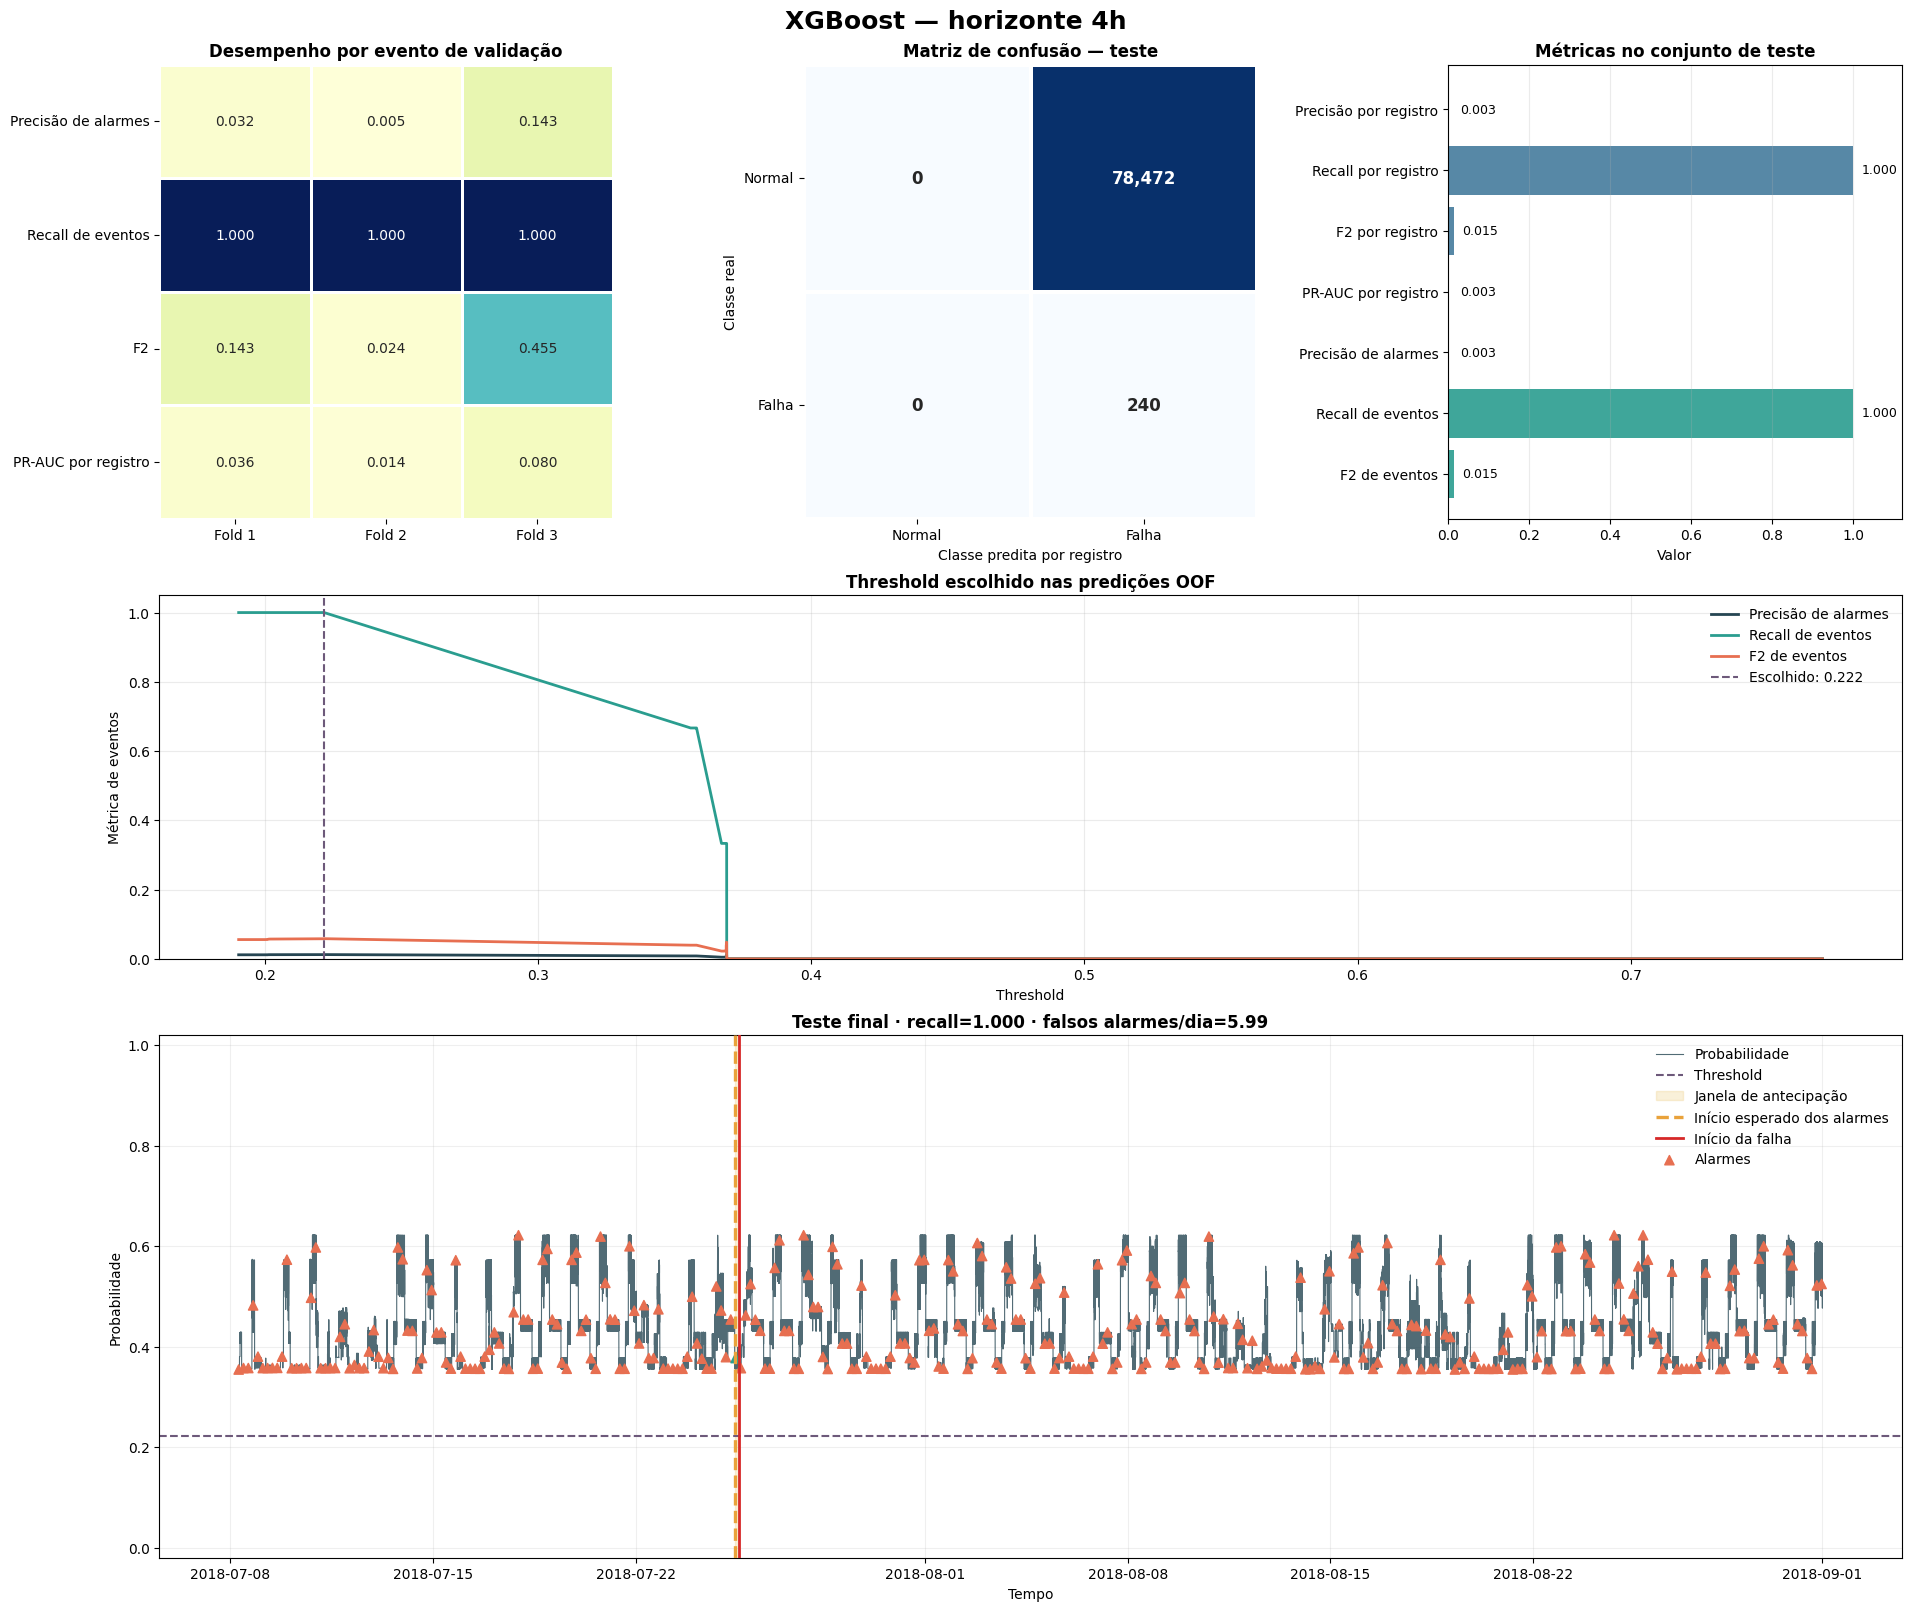

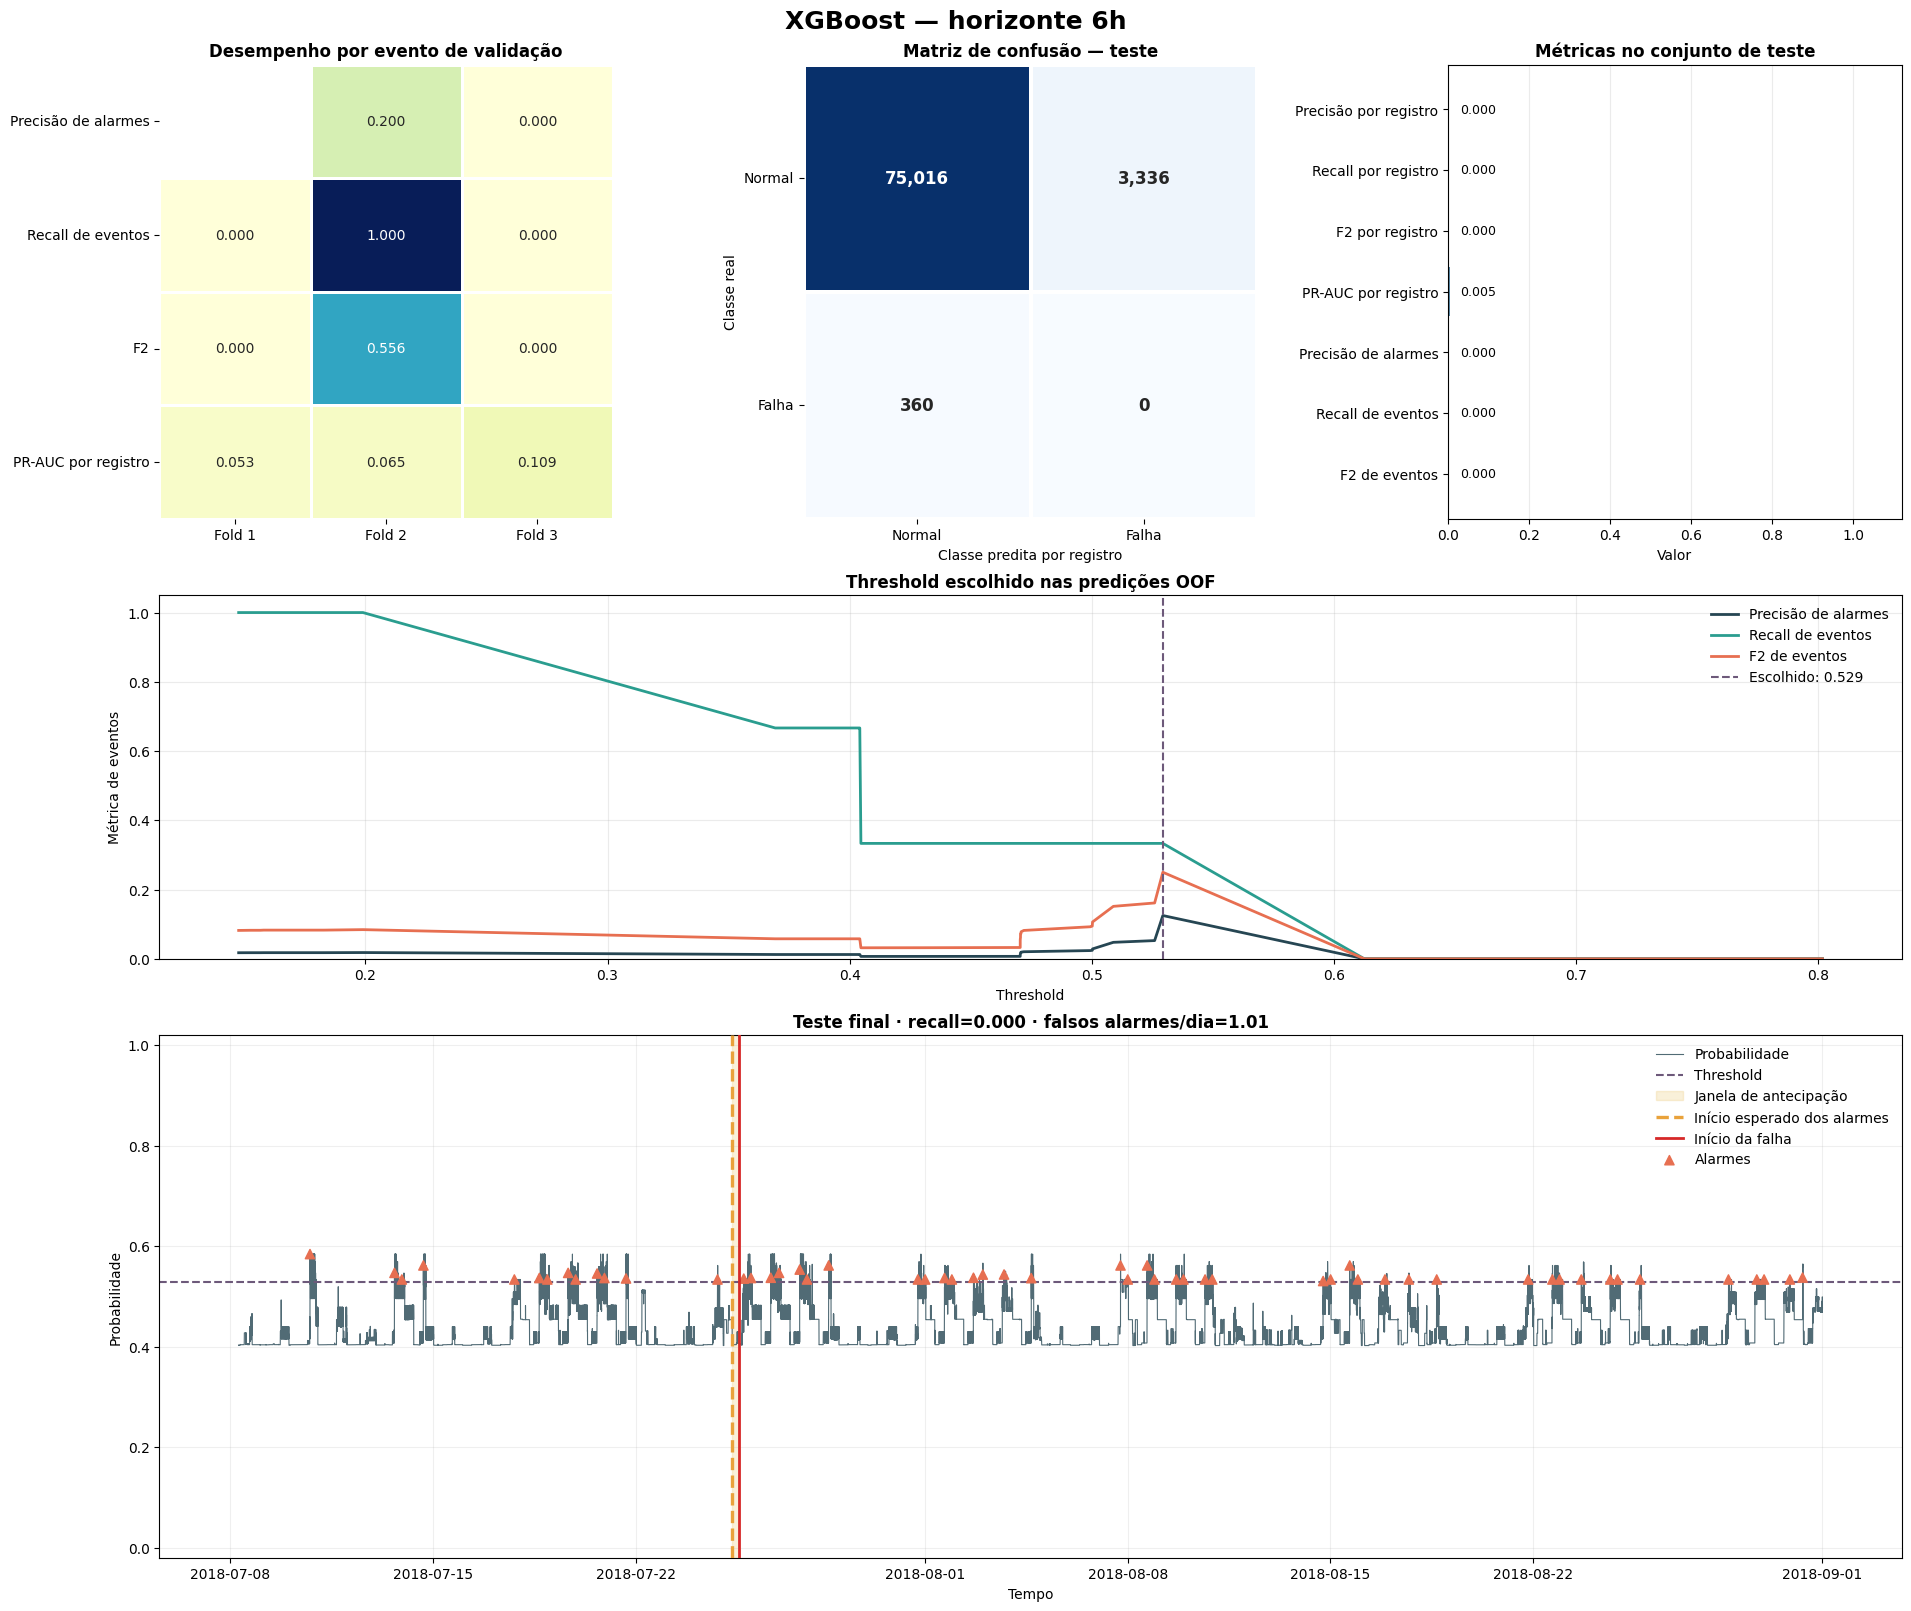

In [16]:
for label in sorted(resultados["XGBoost"], key=pd.Timedelta):
    resultado = resultados["XGBoost"][label]
    print(f"Resultados para {label}:")

    plotar_resultados_modelo(resultado, label)

### Comparação dos modelos

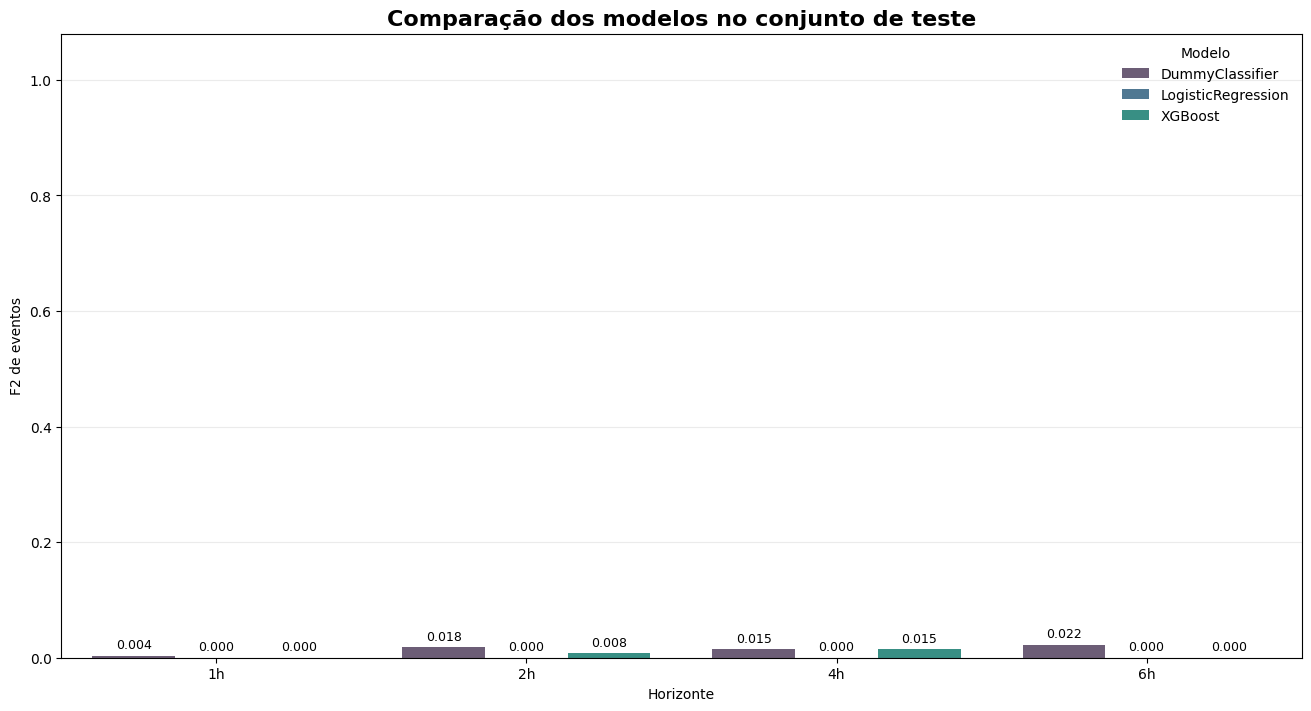

(<Figure size 1300x700 with 1 Axes>,
 <Axes: title={'center': 'Comparação dos modelos no conjunto de teste'}, xlabel='Horizonte', ylabel='F2 de eventos'>)

In [17]:
plotar_comparacao_modelos(resultados)